## **Problem Definition**

### **The Context:**

 - Lending money always carries risk, particularly when borrowers fail to repay their debts. In home equity loans, where the borrower's property secures the loan—defaults can result in substantial financial loss and complex legal recovery. Identifying high-risk applicants early allows financial institutions to make more informed lending decisions, reduce potential losses, and protect the overall health of their loan portfolio.

### **The objective:**

 - The main goal is to build a predictive model that can classify loan applicants as likely to default (BAD = 1) or not (BAD = 0) based on their financial and employment-related features. This model should help credit analysts and decision-makers automate and improve risk assessment at the time of application.

### **The key questions:**

- What features (e.g., debt-to-income ratio, job stability, delinquency history) are the most important indicators of loan default?
- How accurately can we predict loan default using machine learning models?
- Which model provides the best balance between identifying defaulters (recall) and avoiding false positives (precision)?
- Are there missing values or outliers that significantly affect the model’s performance?
- How does the model generalize to unseen data (test set), and is it overfitting?

### **The problem formulation**:
We are dealing with a binary classification problem where the goal is to:
- Use supervised machine learning techniques to predict the binary target variable BAD.
- Given the 12 input features for each applicant, the model should estimate the likelihood of default.
- Evaluate model performance using metrics such as accuracy, precision, recall, F1-score, with special emphasis on recall for class 1 (defaults), since false negatives (missed defaulters) are costlier than false positives.

## **Data Description:**
The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.


* **BAD:** 1 = Client defaulted on loan, 0 = loan repaid

* **LOAN:** Amount of loan approved.

* **MORTDUE:** Amount due on the existing mortgage.

* **VALUE:** Current value of the property.

* **REASON:** Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

* **JOB:** The type of job that loan applicant has such as manager, self, etc.

* **YOJ:** Years at present job.

* **DEROG:** Number of major derogatory reports (which indicates a serious delinquency or late payments).

* **DELINQ:** Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due).

* **CLAGE:** Age of the oldest credit line in months.

* **NINQ:** Number of recent credit inquiries.

* **CLNO:** Number of existing credit lines.

* **DEBTINC:** Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

# **Loan Default Prediction**

## **Import the necessary libraries and Data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,make_scorer,accuracy_score,confusion_matrix,classification_report, recall_score, precision_score, f1_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import scipy.stats as stats

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings('ignore')

## **Data Overview**

- Reading the dataset
- Understanding the shape of the dataset
- Checking the data types
- Checking for missing values
- Checking for duplicated values

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/PDSC/hmeq.csv')

In [4]:
df = data.copy()

In [5]:
# code to display first 5 rows of the data
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [6]:
# code to display last five rows in the data
df.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


In [7]:
# This code will help to check total nimber of rows and columns in our data
df.shape

(5960, 13)

<h2>Observations:<h2>

The dataset contains 5,960 rows and 13 columns.




In [8]:
df.info() # This code will help to check info about data like data type, number of columns,rows etc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


<h2>Observations:<h2>

* All the columns have datatype as integers except for REASON and JOB, which are object datatype.
* Although BAD appears as an integer, it actually represents a binary categorical variable.


In [9]:
df.isnull().sum() # code to check missing values in data

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


<h2>Observations:<h2>

*  All columns, except for the target variable and Loan, contain missing values.
*  I will next examine the percentage of missing values in each column, as percentages provide a clearer picture than raw counts. This helps in determining whether a column should be retained or removed.

In [10]:
(df.isnull().sum() / len(df)) * 100 # Code to calculate the percentage of missing values per column

,0
BAD,0.000000
LOAN,0.000000
MORTDUE,8.691275
VALUE,1.879195
REASON,4.228188
JOB,4.681208
YOJ,8.640940
DEROG,11.879195
DELINQ,9.731544
CLAGE,5.167785


<h2>Observations:<h2>

* All columns have less than 15% missing values, except for DEBTINC.
*  The DEBTINC column has 21% missing values, but we choose to retain it as it reflects an individual's capacity to manage loan repayments. We will also assess its relevance by examining its correlation with the target variable.

In [11]:
df.duplicated().sum()

np.int64(0)

<h2>Observations:<h2>

* There are no duplicate values in the data.




In [12]:
#creating list of categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.append('BAD') # Since the target variable is categorical, we treat it as part of the categorical features.

In [13]:
print(cat_cols)

['REASON', 'JOB', 'BAD']


**Conversion of object dtype:**

* Next, I will convert the object-type columns in cat_cols to the 'category' dtype for improved memory efficiency and faster operations like filtering, grouping, and comparisons.

In [14]:
# code to change categorical columns object data type in category
for col in cat_cols:
  df[col] = df[col].astype('category')
# Verify the changes by checking the data types
print(df[cat_cols].dtypes)

REASON    category
JOB       category
BAD       category
dtype: object


In [15]:
#creating list of numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']


In [16]:
# code to display statistical summary of numerical variables
df.describe(include='number').T   # include ='number' this line is to print summary for numerical columns

,count,mean,std,min,25%,50%,75%,max
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000
DEBTINC,4693.0,33.779915,8.601746,0.524499,29.140031,34.818262,39.003141,203.312149


<h2>Observations:<h2>


*  Loan amounts show substantial variability, with an average near 18,600 and maximum values reaching 89,900.
*  The loan amounts range considerably, averaging about 18,600, with some loans up to 89,900.
*  Loan values range greatly from 8,000 to over 855,000, with an average of about 101,776.
*  Average years on the job is about 9, with a range from 0 to 41 years.
*  Most borrowers have no derogatory reports or delinquencies, but some have up to 10 derogatory reports and 15 delinquencies.
* Credit line ages vary significantly, averaging 15 years but reaching nearly 97 years in some cases.
*  Borrowers have an average of 21 credit lines, ranging from 0 to 71.
* Debt-to-income ratios average 34%, with some extreme outliers exceeding 200%, indicating heavy debt relative to income.











In [17]:
# code to display summary for categorical columns
df.describe(include='category').T # nclude='category' ensures that only categorical variables are included in the summary

,count,unique,top,freq
BAD,5960,2,0,4771
REASON,5708,2,DebtCon,3928
JOB,5681,6,Other,2388


In [18]:
for col in cat_cols:
    print(df[col].value_counts(normalize = True))

    print('*' * 40)

REASON
DebtCon    0.688157
HomeImp    0.311843
Name: proportion, dtype: float64
****************************************
JOB
Other      0.420349
ProfExe    0.224608
Office     0.166872
Mgr        0.135011
Self       0.033973
Sales      0.019187
Name: proportion, dtype: float64
****************************************
BAD
0    0.800503
1    0.199497
Name: proportion, dtype: float64
****************************************


<h2>Observations:<h2>

*  Approximately 80% of applicants successfully repaid their loans, while only about 20% defaulted (indicated by BAD = 1).
* The majority of applicants (approximately 69%) applied for loans to consolidate existing debts (DebtCon = 3,928), while home improvement was a less common reason.
*  The variable includes six categories, with "Other" being the most common, which may encompass self-employment, informal jobs, or less common occupations.

### **Univariate Analysis**


In [19]:
def Hist_boxplot(df, column_name):
    """
    Creates a box plot and histogram for a single numerical column in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the numerical column to plot.
    """
    # Check if the column exists in the DataFrame
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return

    # Check if the column is of a numerical data type
    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"Error: Column '{column_name}' is not a numerical data type.")
        return

    print(f"--- Analyzing Column: {column_name} ---")

    # Create a figure with two subplots (for box plot and histogram)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Box Plot with mean marker
    sns.boxplot(x=df[column_name], ax=axes[0], showmeans=True,
                meanprops={"marker":"*", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":"10"})
    axes[0].set_title(f'Box Plot of {column_name}')
    axes[0].set_xlabel(column_name)

    # Histogram with KDE and mean/median lines
    sns.histplot(x=df[column_name], ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of {column_name}')
    axes[1].set_xlabel(column_name)

    # Add vertical lines for mean and median
    mean_val = df[column_name].mean()
    median_val = df[column_name].median()
    axes[1].axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[1].legend()

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()
    print("\n")

--- Analyzing Column: LOAN ---


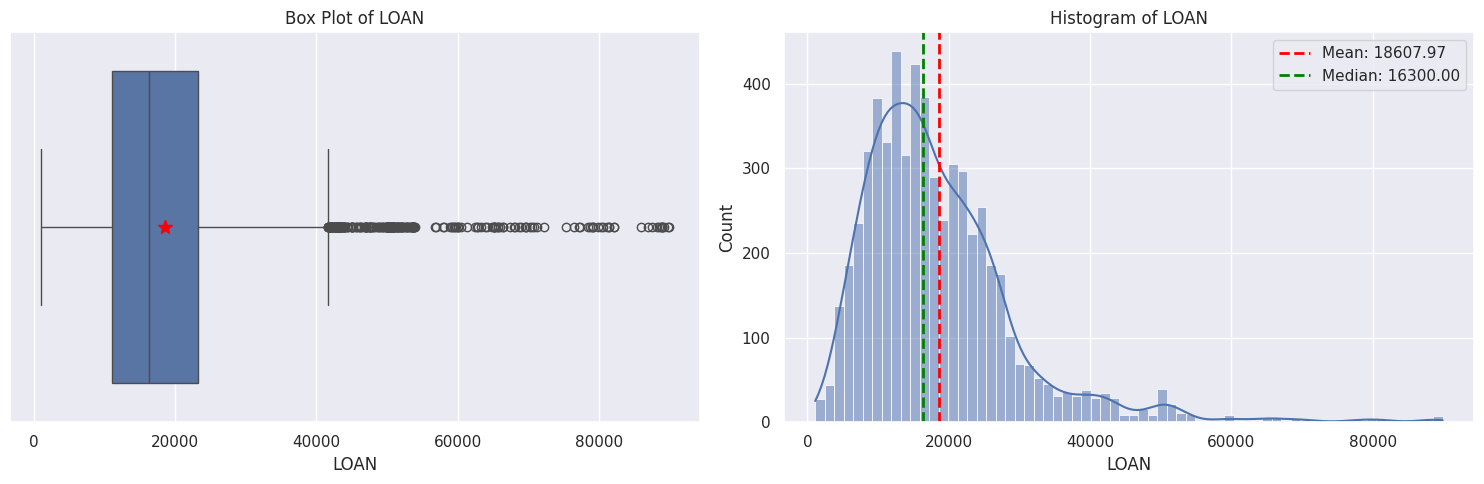

In [20]:
Hist_boxplot(df, 'LOAN') # red star represent mean value

--- Analyzing Column: MORTDUE ---


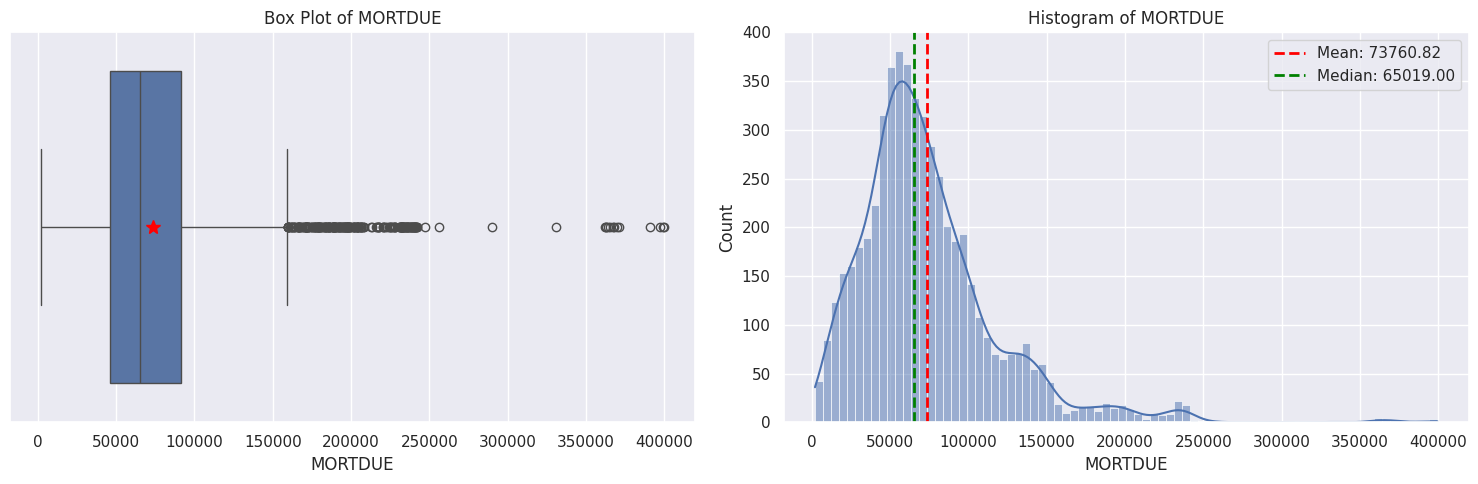

In [21]:
Hist_boxplot(df, 'MORTDUE') # red star represent mean value

--- Analyzing Column: VALUE ---


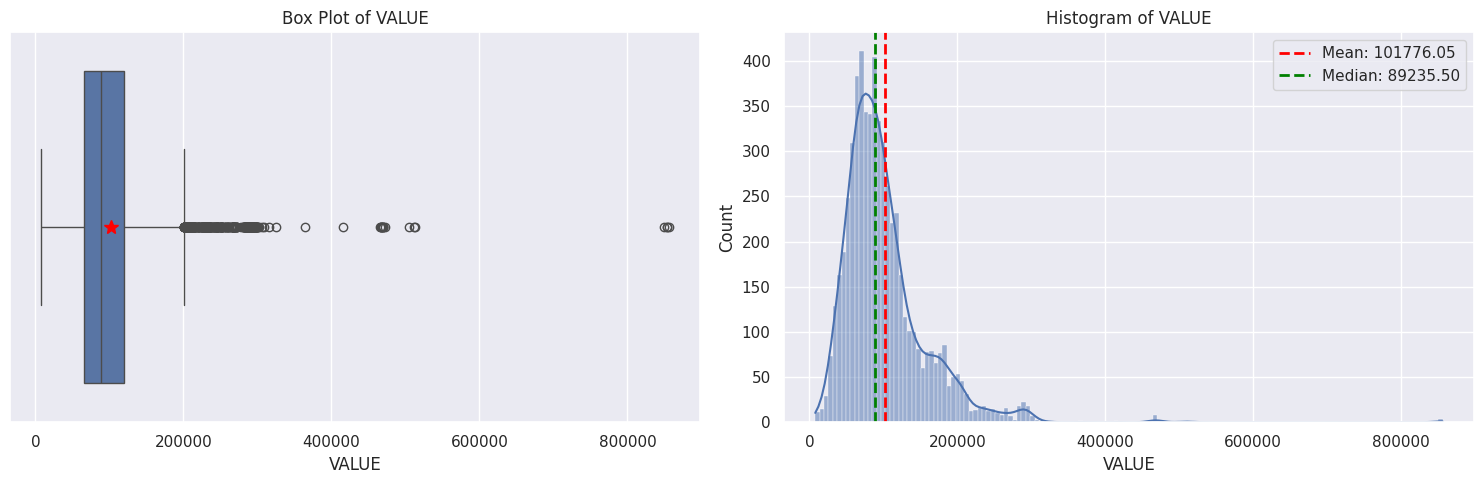

In [22]:
Hist_boxplot(df, 'VALUE') # red star represent mean value

--- Analyzing Column: YOJ ---


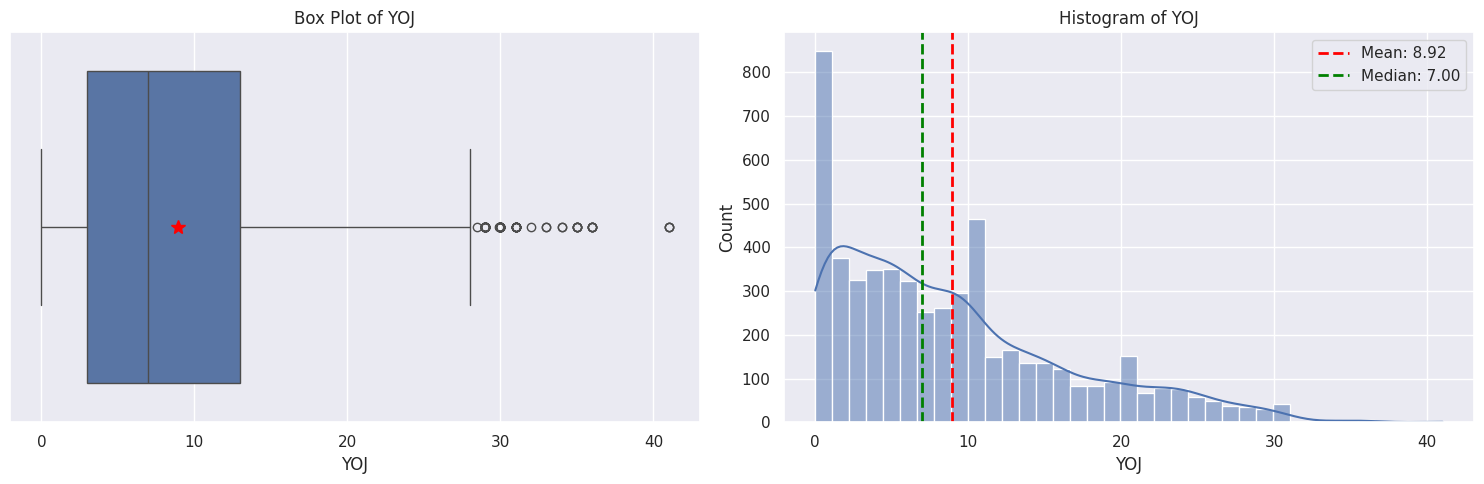

In [23]:
Hist_boxplot(df, 'YOJ') # red star represent mean value

--- Analyzing Column: DEROG ---


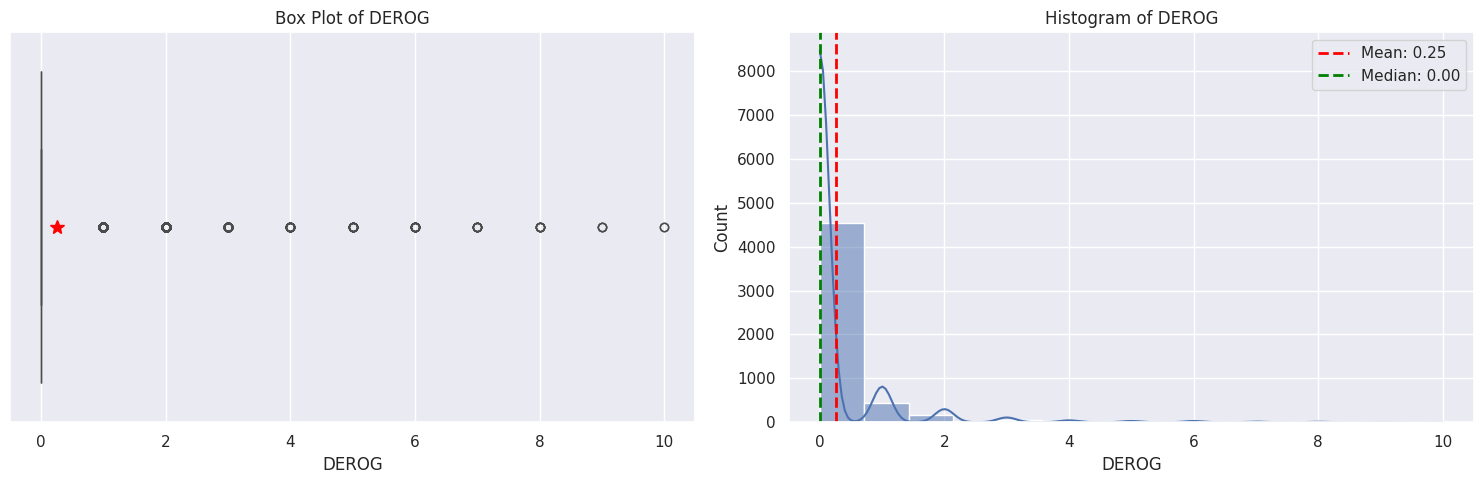

In [24]:
Hist_boxplot(df, 'DEROG') # red star represent mean value

--- Analyzing Column: DELINQ ---


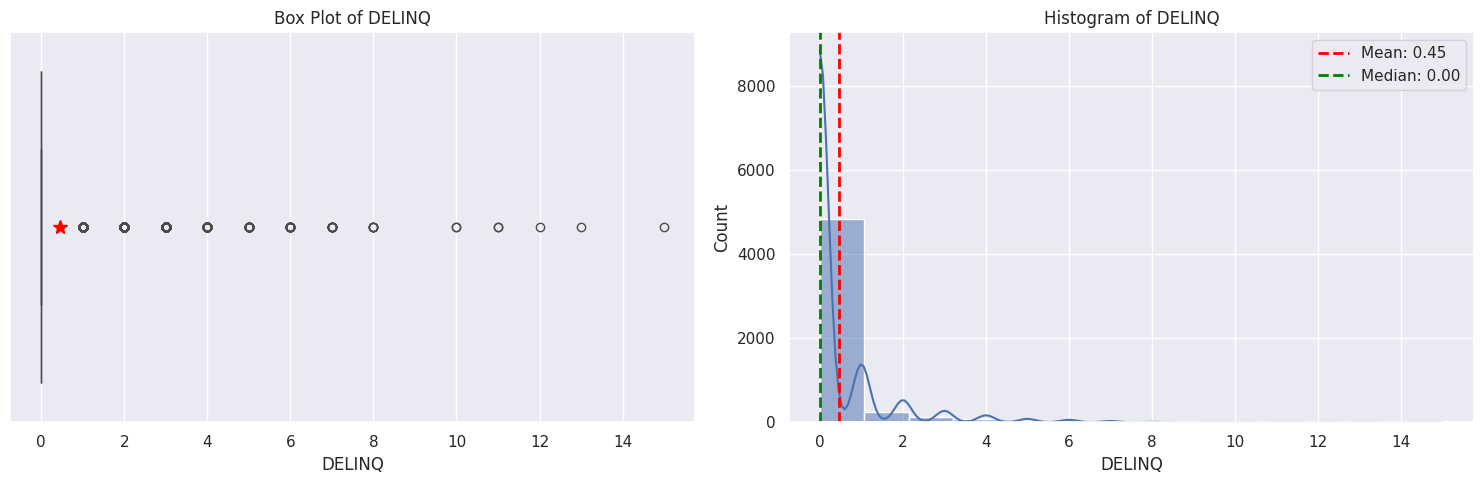

In [25]:
Hist_boxplot(df, 'DELINQ') # red star represent mean value

--- Analyzing Column: CLAGE ---


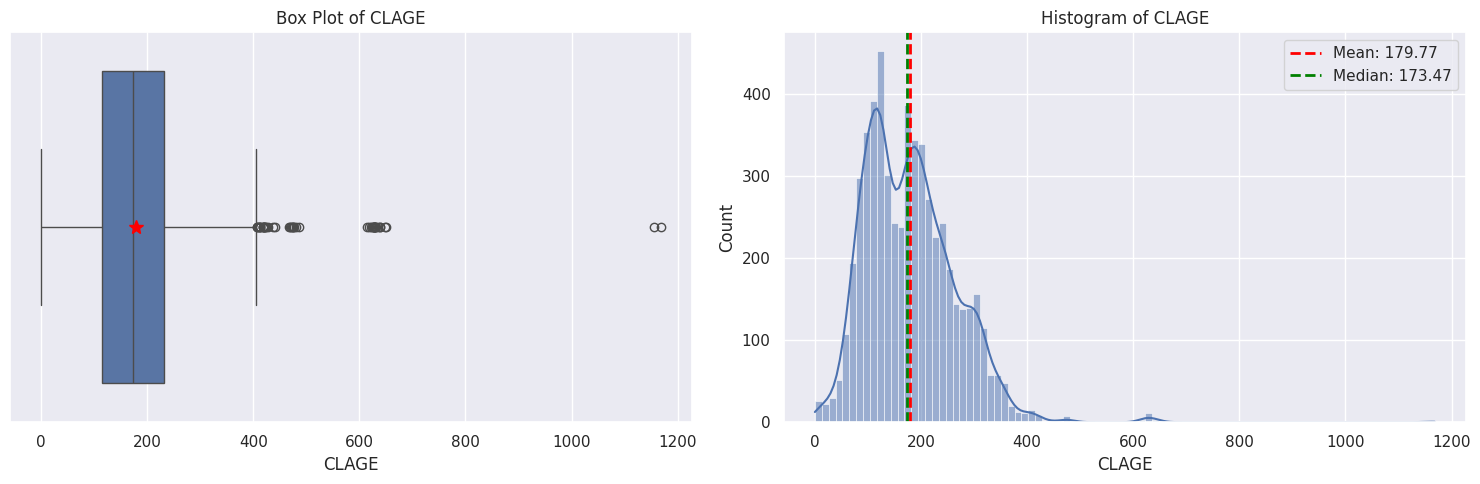

In [26]:
Hist_boxplot(df, 'CLAGE') # red star represent mean value

--- Analyzing Column: NINQ ---


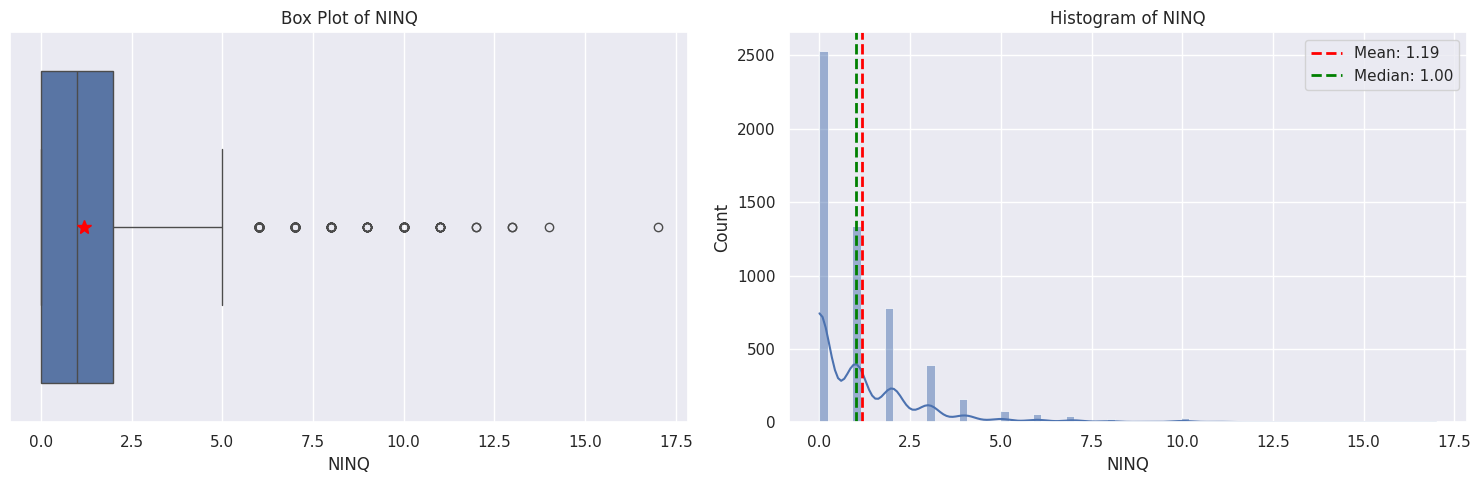

In [27]:
Hist_boxplot(df, 'NINQ') # red star represent mean value

--- Analyzing Column: CLNO ---


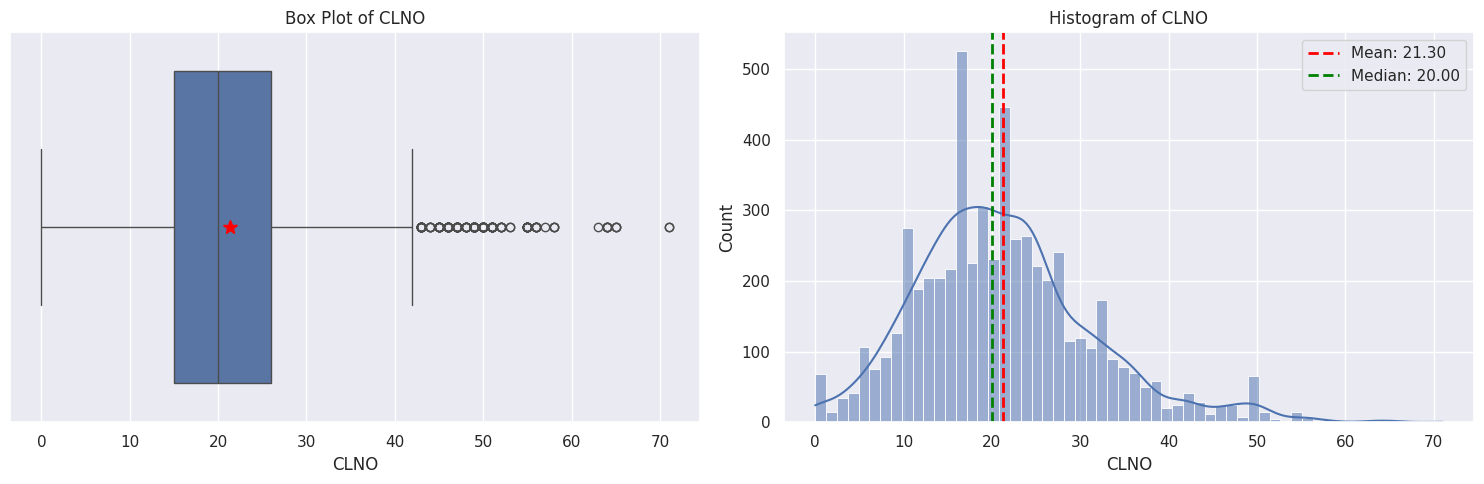

In [28]:
Hist_boxplot(df, 'CLNO') # red star represent mean value

--- Analyzing Column: DEBTINC ---


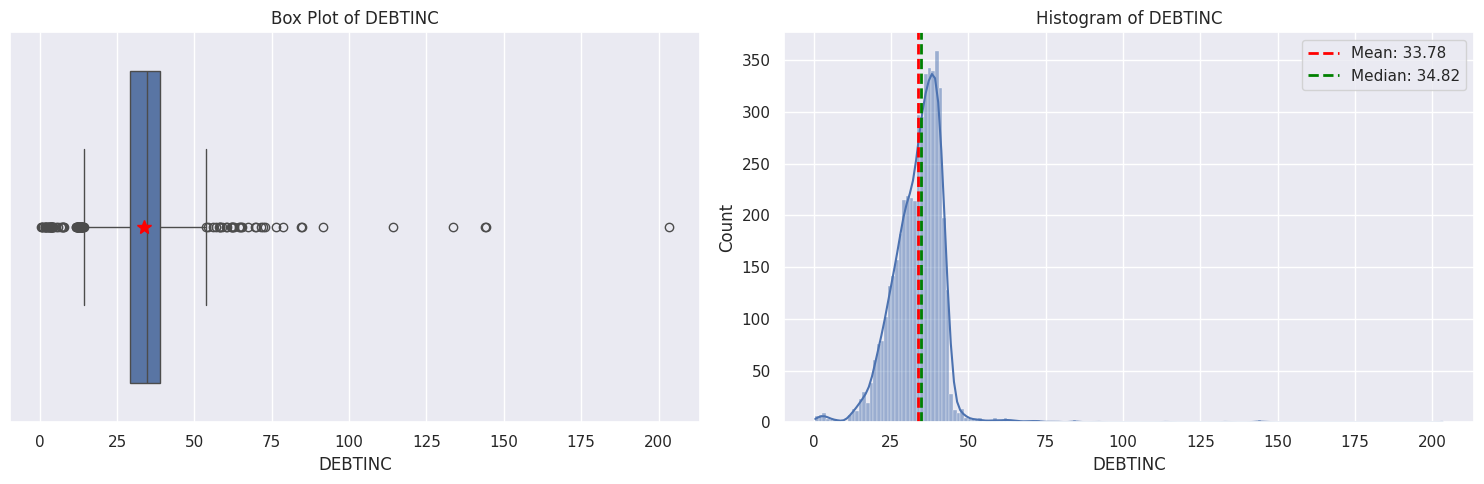

In [29]:
Hist_boxplot(df, 'DEBTINC') # red star represent mean value

<h2>Insights from Univariate Analysis of Numerical Features:</h2>

*   For the numerical variables LOAN, MORTDUE, and VALUE, the mean values are slightly higher than the medians, indicating a mild right-skew in their distributions. This skewness is likely driven by a subset of applicants with notably large loans, mortgages, or property values. The corresponding boxplots highlight the presence of numerous high-value outliers, suggesting the need for careful treatment during data preprocessing.
* The histogram for YOJ indicates a right-skewed distribution, with the mean exceeding the median, suggesting a concentration of lower values and a tail of higher values. The boxplot also reveals the presence of outliers on the upper end.

*  The median values for DEROG (Number of major derogatory reports) and DELINQ (Number of delinquent credit lines) are zero, indicating that the majority of observations are clustered around zero. The means being higher than the medians suggest a right-skewed distribution, which is supported by the presence of outliers in the boxplots.
*   The mean and median values for CLAGE (Age of the oldest credit line in months)and DEBTINC (Debt-to-income ratio) are nearly equal, suggesting a relatively symmetrical distribution. However, the presence of outliers on the higher end introduces a slight right skew in both variables.
*  The histogram for CLNO shows that most values are concentrated near the center, although a few outliers are present on the higher end.
* The distribution of NINQ is right-skewed with most values concentrated between 0 and 2, while a few high outliers (up to 17) pull the mean slightly above the median, indicating that most applicants had few recent credit inquiries.










In [30]:
def perc_on_bar(ax, feature):
    """
    Annotates a bar plot with percentage labels excluding NaN values.

    Parameters:
        ax : matplotlib Axes object
            The axes containing the bar plot.
        feature : pandas Series
            The categorical feature used to create the plot.
    """
    total =len(feature)  # Count only non-NaN values

    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', size=12)

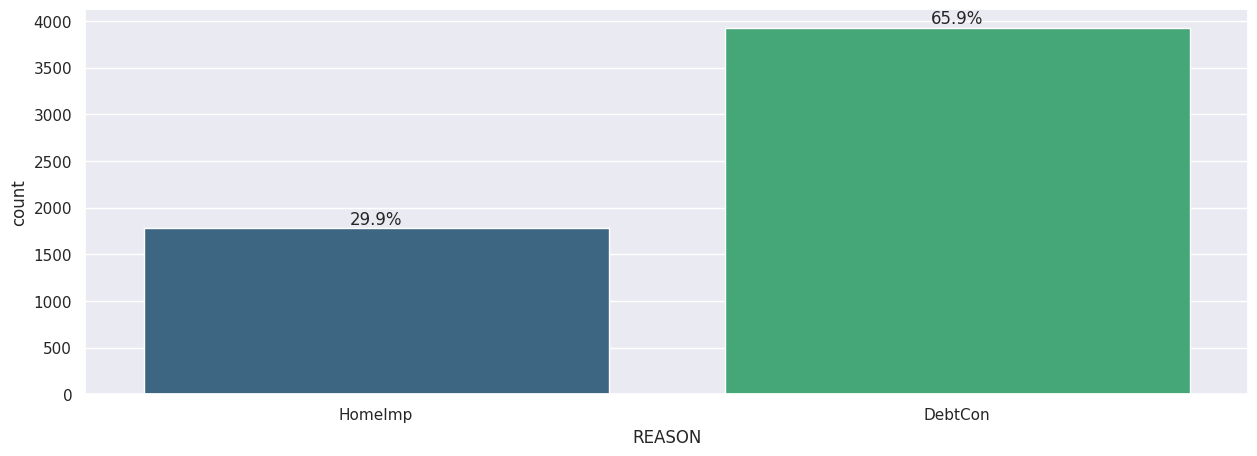

In [31]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x=data["REASON"],palette='viridis')
perc_on_bar(ax,data["REASON"])

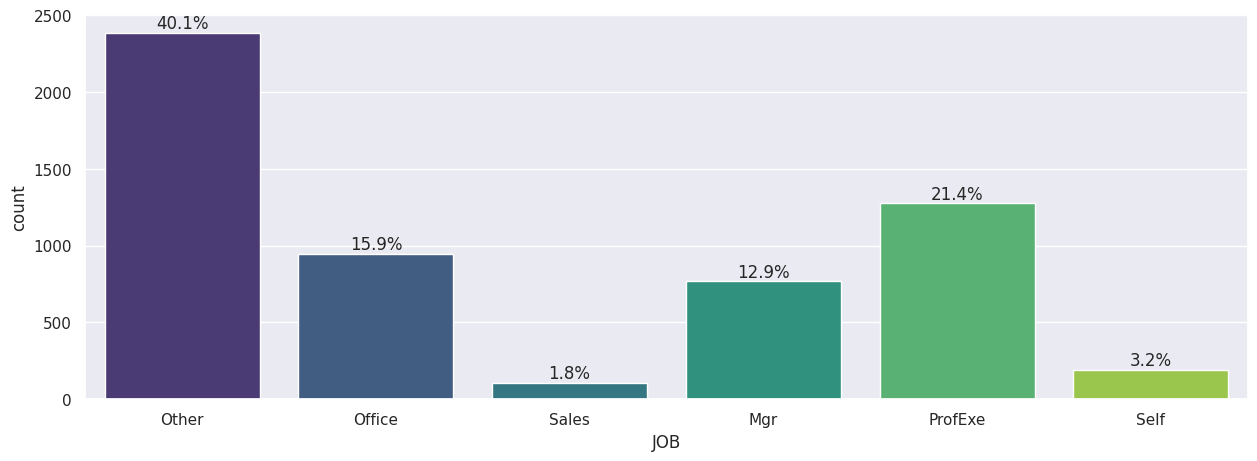

In [32]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x=data["JOB"],palette='viridis')
perc_on_bar(ax,data["JOB"])

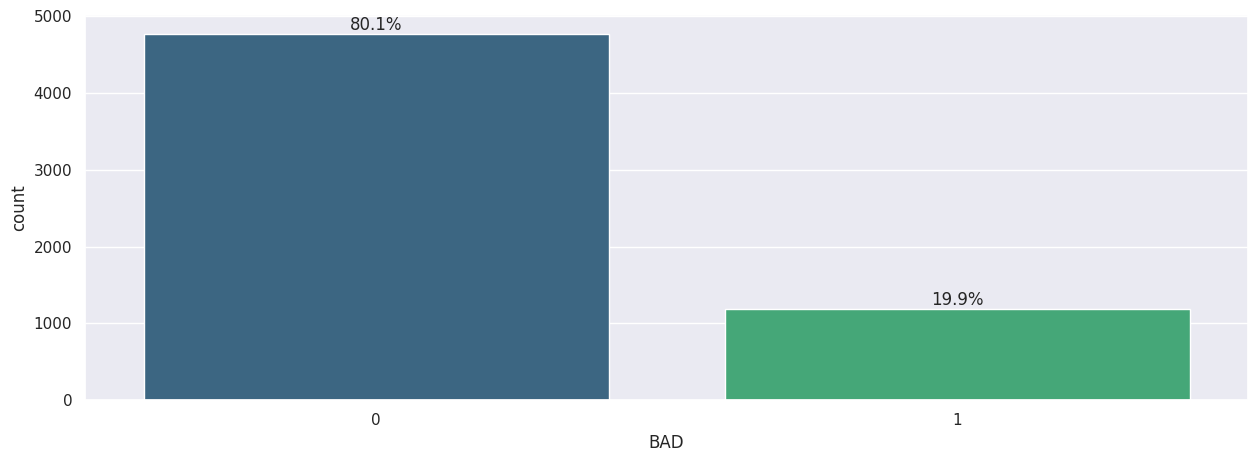

In [33]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x=data["BAD"],palette='viridis')
perc_on_bar(ax,data["BAD"])

<h2> Observations on Univariat Analysis categorical features:<h2>

* Debt consolidation is the primary reason for borrowing, accounting for 66% of loans, followed by home improvement at 30%.
* There are six job categories for loan applicants: Other, Office, Sales, Manager,ProfExe, and Self-employed. The largest group is "Other," comprising roughly 40% of people, followed by "ProfExe" at about 21%.
* Around 80% of borrowers successfully repay their loans, while approximately 20% encounter repayment difficulties





### **Bivariate Analysis**

In [34]:
# Function to calculate stacked barplot

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins = True).sort_values(
        by = sorter, ascending = False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize = "index").sort_values(
        by = sorter, ascending = False
    )
    tab.plot(kind = "bar", stacked = True, figsize = (count + 1, 5))
    plt.legend(
        loc = "lower left",
        frameon = False,
    )
    plt.legend(loc = "upper left", bbox_to_anchor = (1, 1))
    plt.show()

BAD         0     1   All
REASON                   
All      4567  1141  5708
DebtCon  3183   745  3928
HomeImp  1384   396  1780
------------------------------------------------------------------------------------------------------------------------


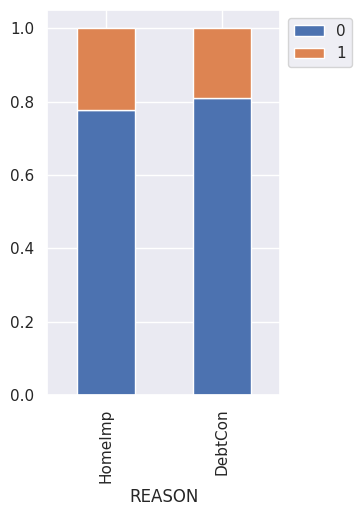

In [35]:
stacked_barplot(df, 'REASON', 'BAD')

BAD         0     1   All
JOB                      
All      4515  1166  5681
Other    1834   554  2388
ProfExe  1064   212  1276
Mgr       588   179   767
Office    823   125   948
Self      135    58   193
Sales      71    38   109
------------------------------------------------------------------------------------------------------------------------


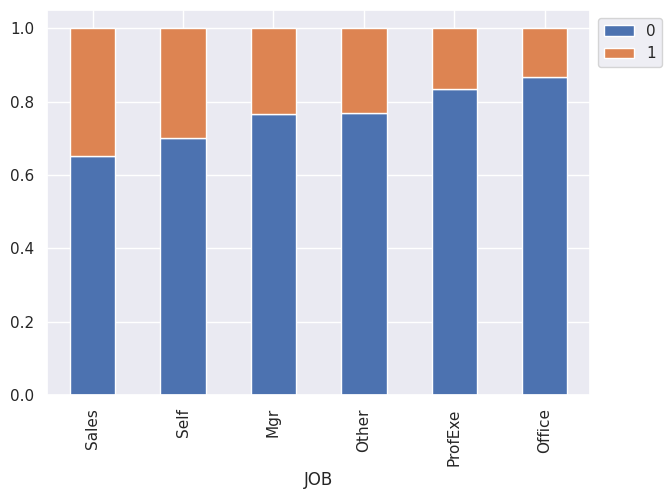

In [36]:
stacked_barplot(df, 'JOB', 'BAD')

<h2>Observations on Relationships Between Categorical Variables and Target:<h2>

* Home improvement loans account for 22% of defaults, followed by debt consolidation loans at 19%.
* The highest default rate is among individuals in Sales (35%), followed by Self-employed (30%), Managers and Others (both at 23%). Office workers have the lowest share of defaults at 13%.



In [38]:
def boxplots_numerical_vs_target(df, target_col, palette='viridis'):
    """
    Plots boxplots for all numerical columns in the DataFrame against a categorical target variable.

    Parameters:
        df (DataFrame): The input DataFrame
        target_col (str): The name of the categorical target column
        palette (str): Color palette for the boxplots
    """
    numerical_cols = df.select_dtypes(include=['number']).columns.drop(target_col, errors='ignore')

    for col in numerical_cols:
        plt.figure(figsize=(8, 8))
        sns.boxplot(data=df, x=target_col, y=col, palette=palette)
        plt.title(f'{col} vs {target_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

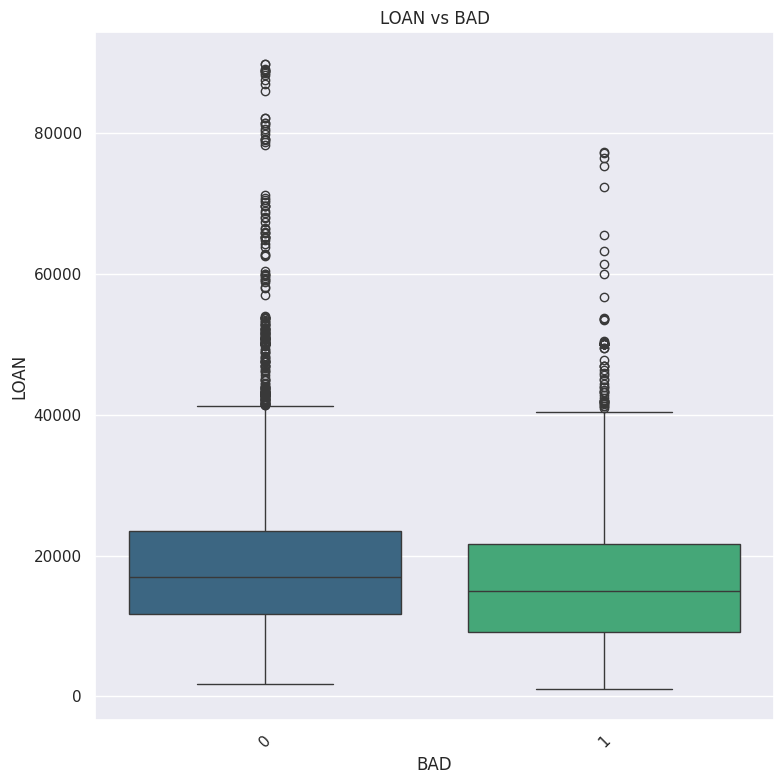

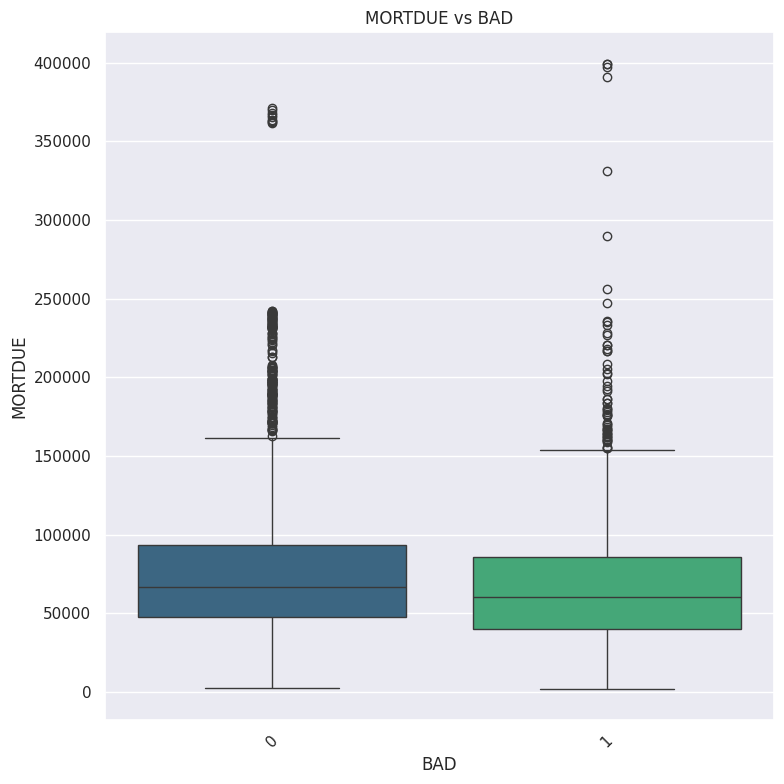

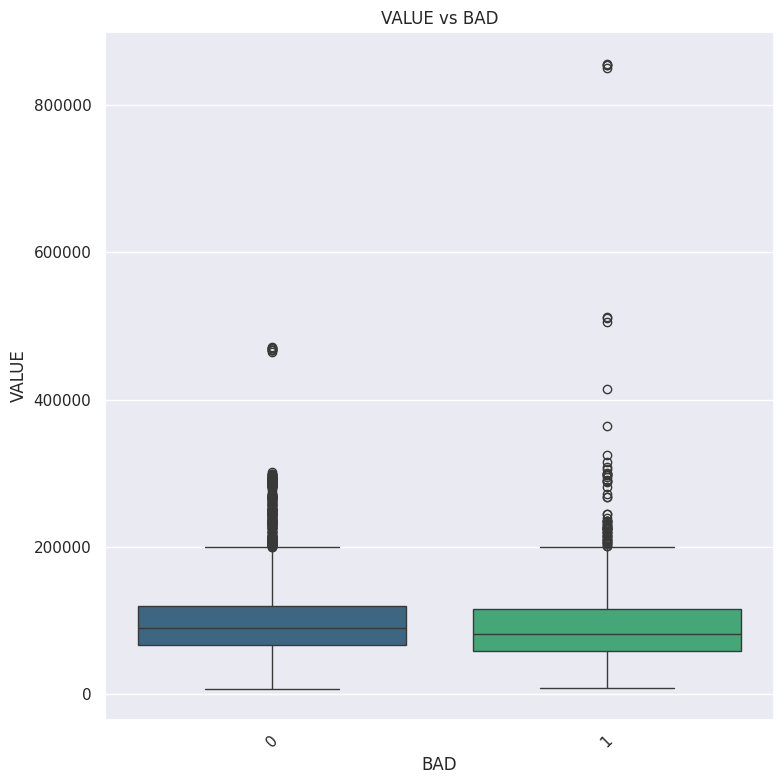

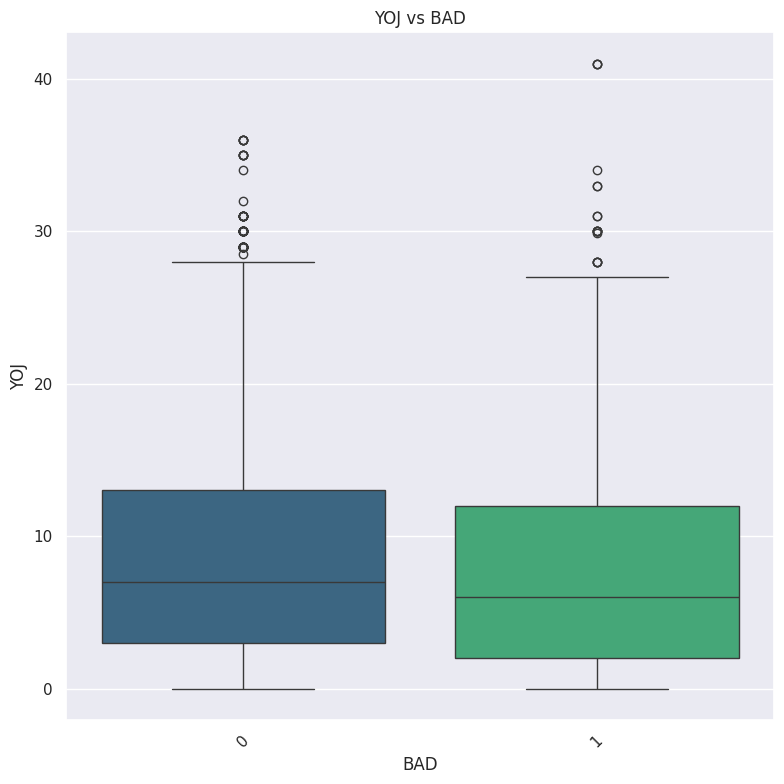

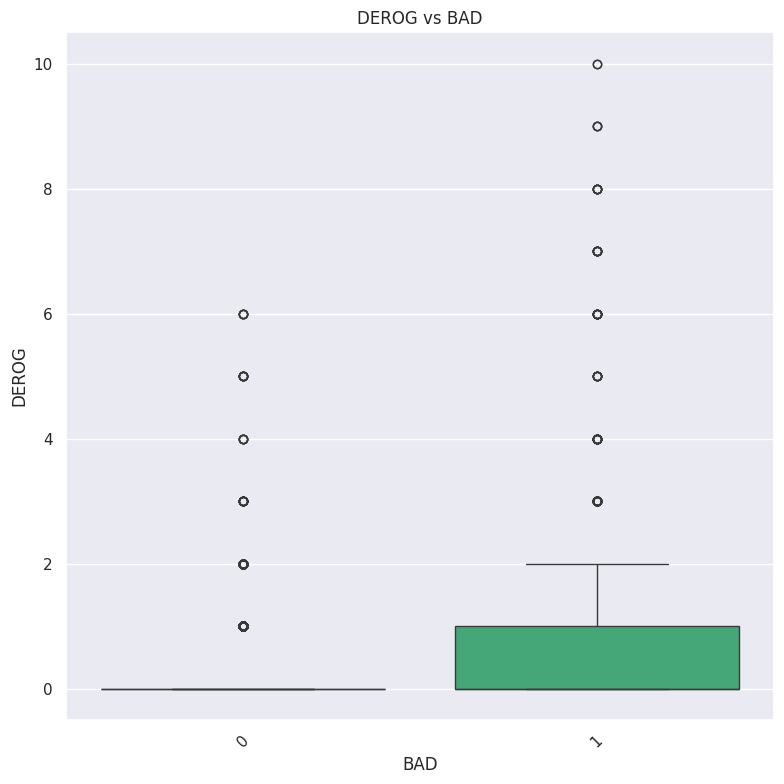

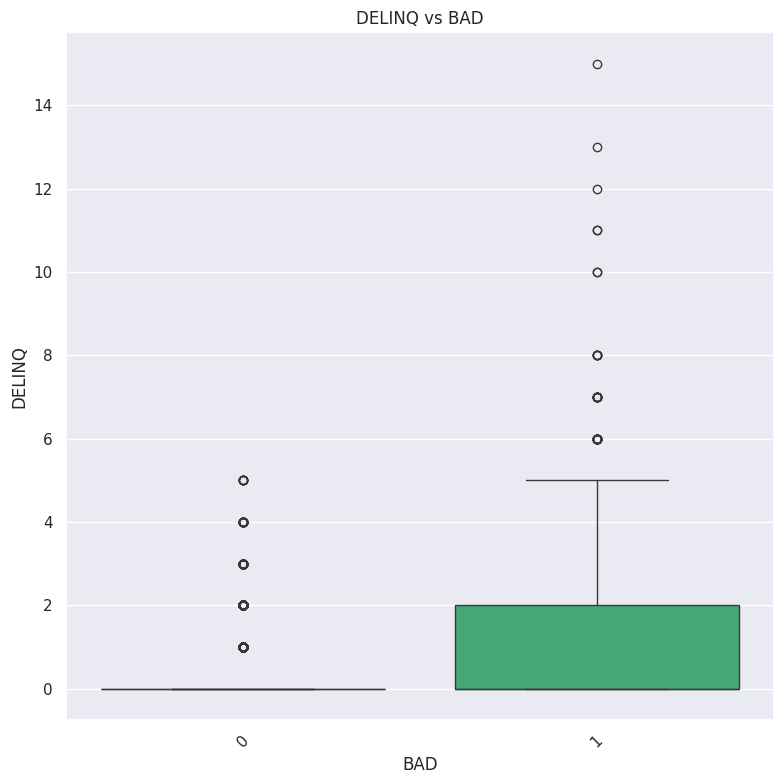

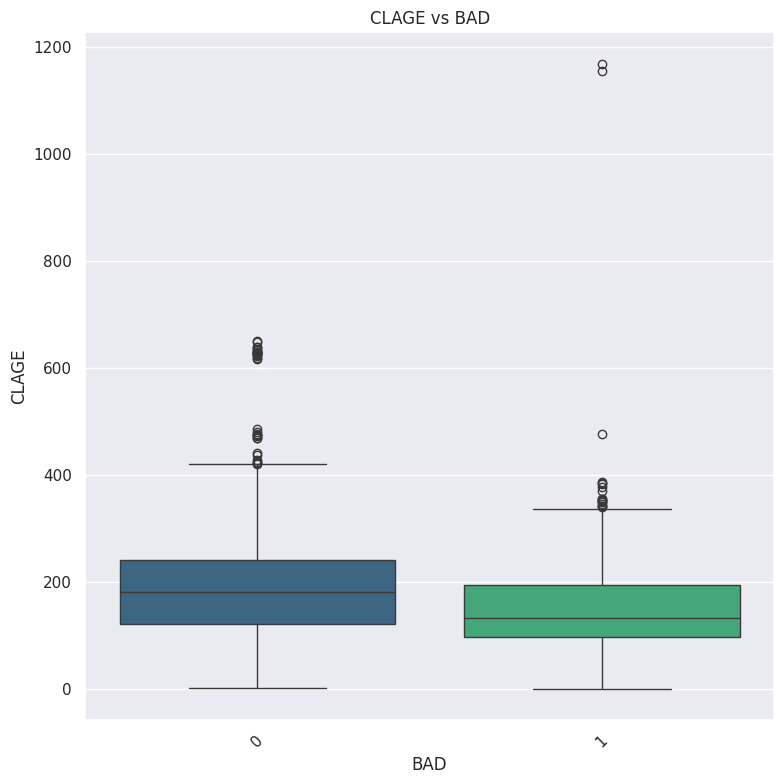

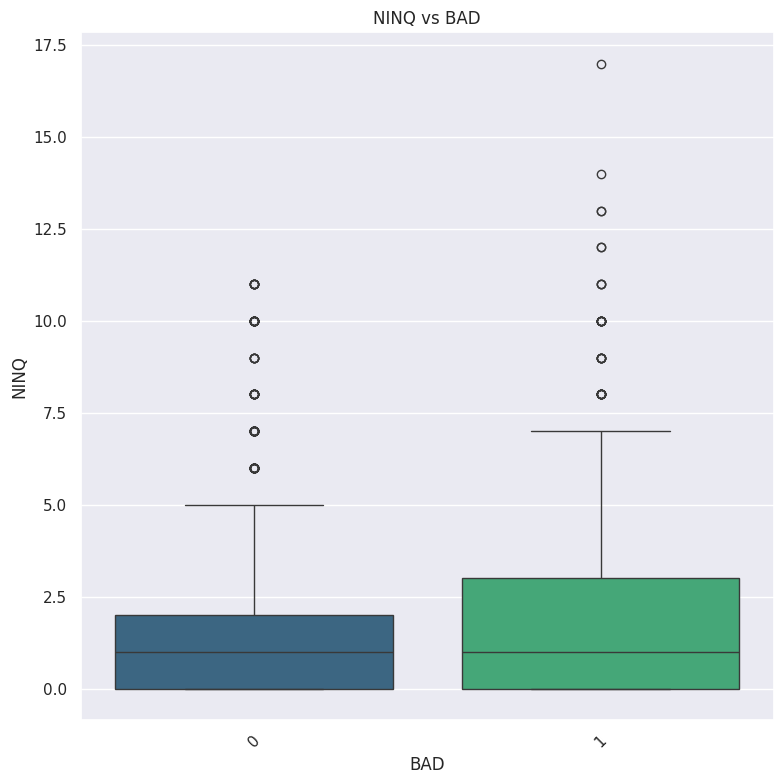

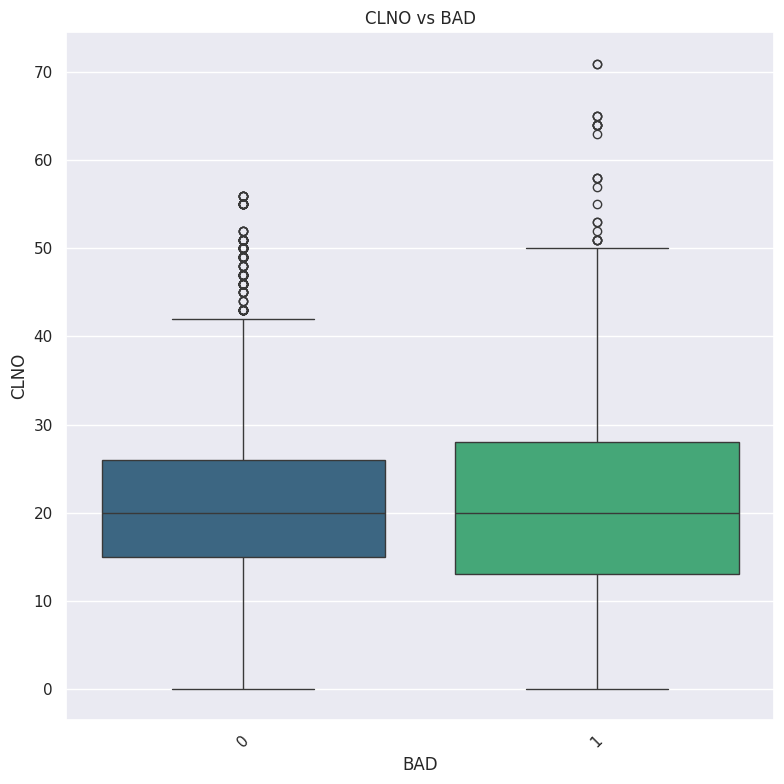

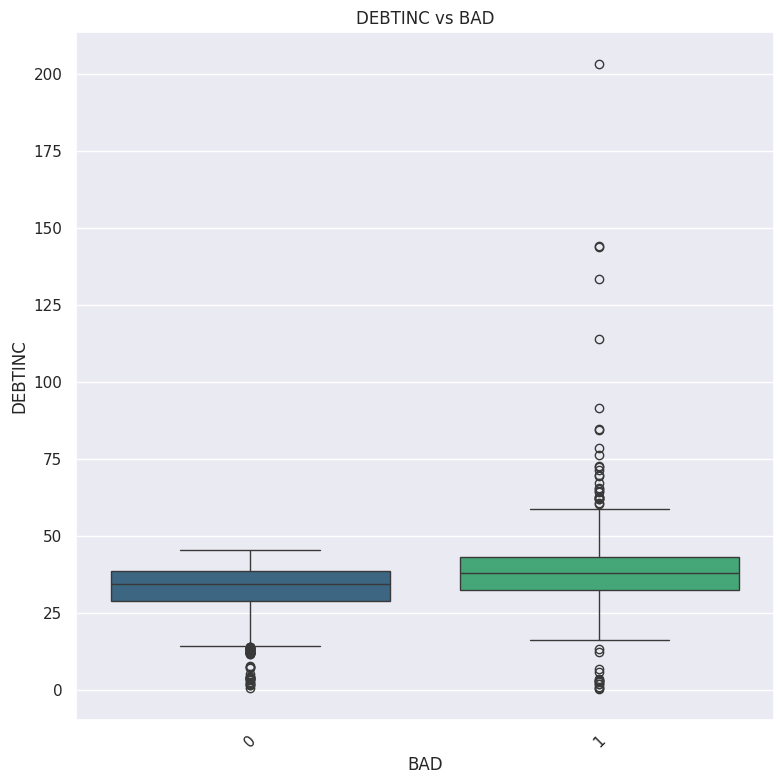

In [39]:
boxplots_numerical_vs_target(df, target_col='BAD')

<h2>Obervations:<h2>

* The median values for both LOAN and MORTDUE are slightly higher among non-defaulters (BAD = 0), with similar interquartile ranges across both defaulter and non-defaulter groups. While both variables show a high number of outliers, higher amounts appear in both categories. Overall, neither loan amount nor mortgage due alone serve as strong indicators of default risk.

* The range of the current value of the property is the same for both defaulter and non-defaulter groups, while the interquartile range is slightly wider for the defaulter group, indicating slightly more variation in typical property values among defaulters. However, both groups show a significant number of outliers, suggesting that there are individuals in each group who own properties with values far above the typical range
* The average number of years at the current job (YOJ) is slightly higher for the non-defaulter group, with outliers present in both defaulters and non-defaulters.
*  Non-defaulters typically have zero values for DEROG and DELINQ, with minimal outliers. For defaulters, DEROG ranges from 0 to 2 and DELINQ from 0 to 5, might be indicating higher credit issues and some extreme cases
*  The CLAGE values are higher for the non-defaulter group, indicating that they typically have longer-established credit histories. Outliers are observed in both groups, showing some variation beyond the normal range.
* The defaulter group has a wider range of values for both recent credit inquiries (NINQ) and number of open credit lines (CNO). This means their credit activity varies more — some have very few inquiries or accounts, while others have a lot. This could suggest more unpredictable or risky credit behavior among defaulters.
* Defaulters exhibit a larger range and interquartile range in DEBTINC values, with outliers present on both the low and high sides. In contrast, non-defaulters have a narrower range and fewer outliers, mostly below the lower whisker. This implies defaulters face more irregular and sometimes higher debt relative to income, contributing to repayment.









### **Multivariate Analysis**

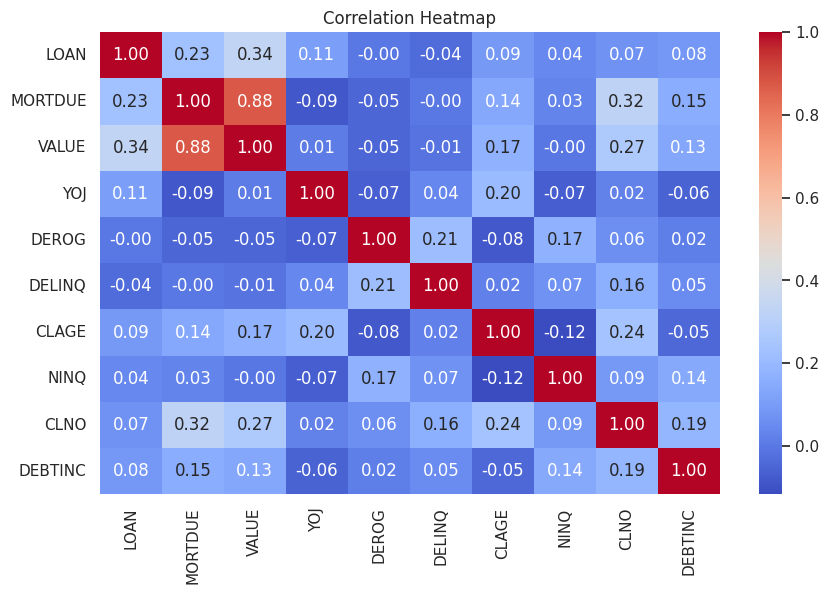

In [40]:
# This will help to plot heatmap to check relation between numeric variables
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm',fmt='0.2f')
plt.title('Correlation Heatmap')
plt.show()

<h2> Observations:<h2>

*   MORTDUE and VALUE show a very strong positive correlation (0.88), suggesting that as property value increases, the mortgage due amount also tends to be higher.
* LOAN and VALUE (0.34) and LOAN and MORTDUE (0.23) also show moderate positive correlations, implying that higher-valued properties and higher mortgage dues are associated with slightly larger loan amounts.
* Most other variables show weak or negligible correlation (close to 0) with each other and with LOAN.
* DEROG, DELINQ, and NINQ have almost no correlation with LOAN or VALUE, indicating that the number of delinquencies or inquiries has little linear relationship with loan amount or property value.
* CLNO and MORTDUE (0.32) and CLNO and VALUE (0.27): Suggests that people who have more credit accounts usually owe more on their mortgage and their homes tend to be worth a bit more.
*  DEBTINC and CLNO (0.19) and DEBTINC and MORTDUE (0.15): A weak positive relationship, implying that higher debt-to-income ratios may be slightly associated with higher mortgage debt and more credit lines.



In [41]:
sns.pairplot(df, hue='BAD')

plt.show()

Output hidden; open in https://colab.research.google.com to view.

<h2>Observations:<h2>

* VALUE and MORTDUE show a clear positive trend, confirming their strong correlation from the heatmap. Both also show a pattern where non-defaulters (blue) dominate the higher value ranges
* If we look at the pair plot for CLAGE and YOJ, we observe non-defaulters tend to have longer job tenure and older credit history.
*  Defaulters are more frequently associated with non-zero values in DEROG, DELINQ, and NINQ, indicating a history of credit problems and recent credit activity.
* The plot for VALUE shows that non-defaulters typically own higher-valued properties.
* Features like DEROG, DELINQ, and NINQ might be useful for modeling credit risk, especially in combination with others.







<h1> Data Preprocessing: Missing Values & Outlier Handling<h1>

* Our dataset has missing values in many columns, so we will handle those first.
* Since most columns also contain outliers that could affect model performance, we will treat them before using logistic regression.



In [265]:
#1.  Make a copy of your original dataset
df_new = data.copy()
missing_col = [col for col in df_new.columns if df_new[col].isnull().any()]

def add_binary_flag(df_new, col):
    new_col = f"{col}_missing_values_flag"
    df_new[new_col] = df_new[col].isna()
    return df_new
for colmn in missing_col:
    df_new = add_binary_flag(df_new, colmn)



In [266]:
#3. Fill missing values
num_data = df_new.select_dtypes('number') # define numercal columns for new copy
cat_data = df_new.select_dtypes('category').columns.tolist() #define categorical columns

df_new[num_data.columns] = num_data.fillna(num_data.median()) #fill missing values in numerical columns with median
for col in cat_data:
    df_new[col] = df_new[col].fillna(df_new[col].mode()[0]) #ill missing values in categorical columns with mode

In [267]:
# 4. Treat outliers
def treat_outliers(df1, col):
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower = Q1 - 1.5 * IQR
    Upper = Q3 + 1.5 * IQR
    df1[col] = np.clip(df1[col], Lower, Upper)
    return df1

def treat_outliers_all(df1, col_list):
    for col in col_list:
        df1 = treat_outliers(df1, col)
    return df1

In [268]:
numerical_col = df_new.select_dtypes(include=np.number).columns.tolist()
numerical_col.remove('BAD')  # exclude target
df1 = treat_outliers_all(df_new, numerical_col)

## **Model Building - Approach**
- Data preparation
- Partition the data into train and test set
- Build the model
- Fit on the train data
- Tune the model
- Test the model on test set

In [269]:
# 5. Define X and y AFTER all preprocessing
X = df1.drop('BAD', axis=1)
y = df1['BAD']


In [270]:
# 6. One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [271]:
#7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

In [272]:
# Checking the shape of the train and test data
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Shape of label in training set :", y_train.shape)
print("Shape of label in test set :", y_test.shape)

Shape of Training set :  (4172, 27)
Shape of test set :  (1788, 27)
Shape of label in training set : (4172,)
Shape of label in test set : (1788,)


In [273]:
print("\nUnique values in y_train:", y_train.unique())


Unique values in y_train: [0 1]


### Logistic Regression


Model can make two wrong predictions here False negative and False positive

* A defaulter is incorrectly predicted not to default, even though it actually defaults.(False negative)
* A non-defaulter is incorrectly predicted to default, even though it never default (False positive)

A false negative is especially critical because misclassifying an actual defaulter as creditworthy can lead to direct financial loss, increased recovery costs, and long-term damage to the company's credit portfolio and reputation.

The company aims to maximize recall, as a higher recall score reduces the likelihood of false negatives. I will begin by defining functions to compute various metrics and the confusion matrix, so I can reuse them across different models.

In [274]:
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Eligible', 'Eligible'], yticklabels=['Not Eligible', 'Eligible'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [275]:
lg = LogisticRegression() # logistic regression model
lg.fit(X_train, y_train)

LogisticRegression()

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      3340
           1       0.58      0.04      0.08       832

    accuracy                           0.80      4172
   macro avg       0.69      0.52      0.49      4172
weighted avg       0.76      0.80      0.73      4172



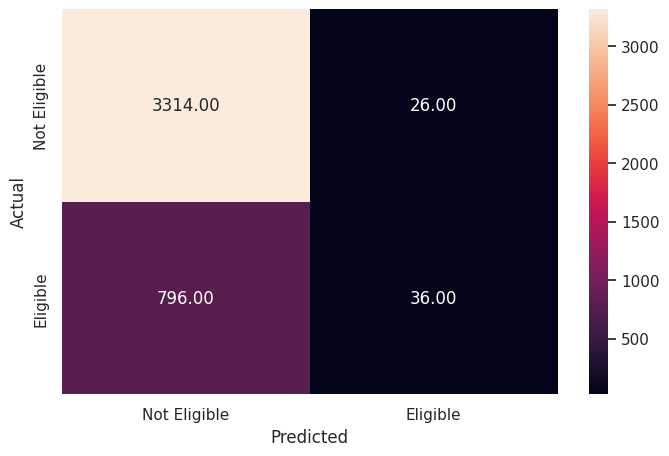

In [276]:
y_pred_train = lg.predict(X_train)

metrics_score(y_train, y_pred_train)

              precision    recall  f1-score   support

           0       0.81      0.99      0.89      1431
           1       0.50      0.04      0.08       357

    accuracy                           0.80      1788
   macro avg       0.65      0.52      0.48      1788
weighted avg       0.74      0.80      0.73      1788



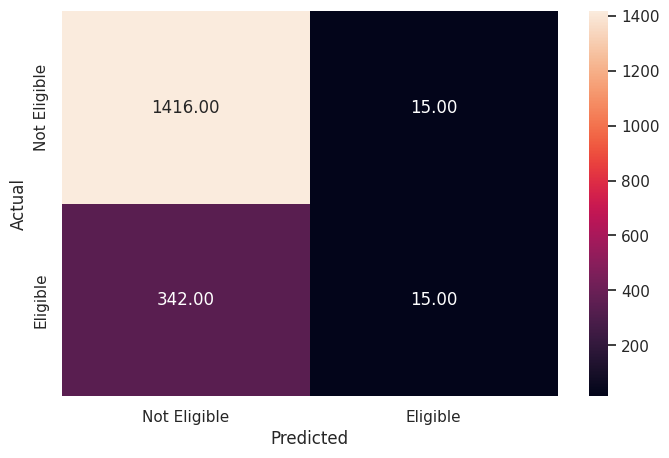

In [277]:
y_pred_test = lg.predict(X_test)
metrics_score(y_test, y_pred_test)

###Observations on LogisticRegression model:


*  The model performance is poor for both train and test data as recall is very low.
*  The model shows high accuracy (around 80%), largely driven by excellent performance on class 0 (non-defaulters), with precision and recall both near 1.00. However, it performs very poorly on class 1 (defaulters) — the recall is only 4%, indicating the model is failing to identify the majority of actual defaulters. Precision for class 1 is also low (0.58 for train and 0,50 for test), but this is less critical than the recall in credit risk scenarios. The F1-score for class 1 is very poor (0.08), reflecting the imbalance in performance between precision and recall.
*  This result suggests the model is highly biased towards the majority class (non-defaulters) and would not be suitable for use in production without improving its ability to correctly classify defaulters.

##Let's set the threshild for our model to improve performance##



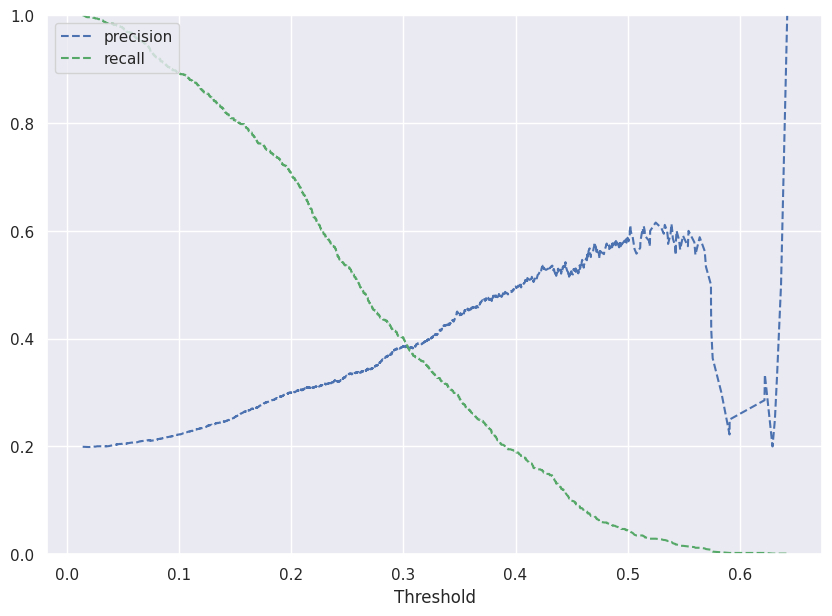

In [280]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score, precision_recall_curve
y_scores_lg = lg.predict_proba(X_train) # predict_proba gives the probability of each observation belonging to each class


precisions_lg, recalls_lg, thresholds_lg = precision_recall_curve(y_train, y_scores_lg[:, 1])

# Plot values of precisions, recalls, and thresholds
plt.figure(figsize = (10, 7))

plt.plot(thresholds_lg, precisions_lg[:-1], 'b--', label = 'precision')

plt.plot(thresholds_lg, recalls_lg[:-1], 'g--', label = 'recall')

plt.xlabel('Threshold')

plt.legend(loc = 'upper left')

plt.ylim([0, 1])

plt.show()

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      3340
           1       0.39      0.37      0.38       832

    accuracy                           0.76      4172
   macro avg       0.62      0.61      0.61      4172
weighted avg       0.75      0.76      0.76      4172



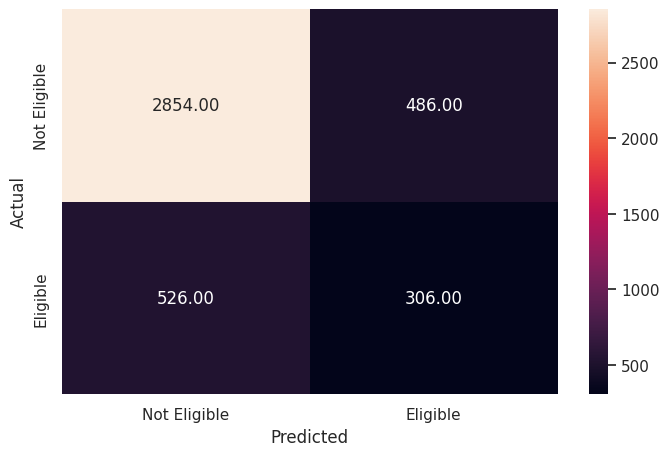

In [282]:
optimal_threshold1 = .31

y_pred_train = lg.predict_proba(X_train)

metrics_score(y_train, y_pred_train[:, 1] > optimal_threshold1)

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1431
           1       0.39      0.37      0.38       357

    accuracy                           0.76      1788
   macro avg       0.61      0.61      0.61      1788
weighted avg       0.75      0.76      0.75      1788



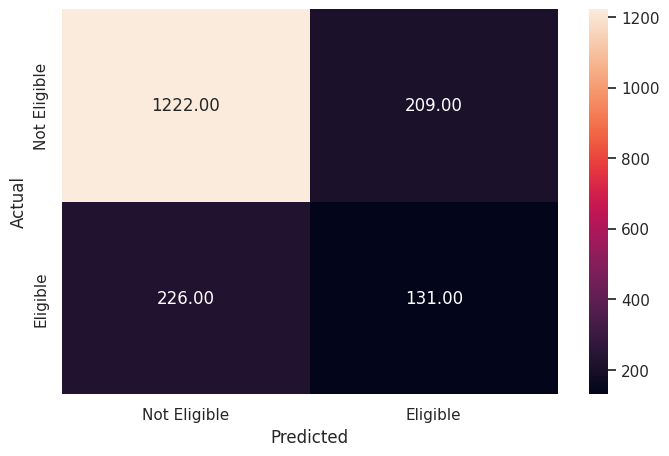

In [283]:
optimal_threshold1 = .31

y_pred_test = lg.predict_proba(X_test)

metrics_score(y_test, y_pred_test[:, 1] > optimal_threshold1)

### Impact of Custom Threshold on Model Predictions
After adjusting the threshold to 0.31, the logistic regression model shows balanced performance across training and test datasets

* For both train and test sets, the overall accuracy is 76%, and the weighted averages for precision, recall, and F1-score remain consistent at around 0.76, indicating stable generalization.
* The model performs well for class 0 (non-defaulters), achieving high precision (0.84) and recall (0.85).
* However, for class 1 (defaulters), performance improves slightly compared to default threshold (0.5), with recall rising to 0.37 and precision to 0.39. This reflects better sensitivity to identifying defaulters, though there is still significant room for improvement.

Overall, adjusting the threshold has helped capture more defaulters, which is important in credit risk contexts where false negatives are costly. More work is needed to enhance class 1 recall while keeping precision balanced.







### Decision Tree
### Data preprocessing for tree-based models
For tree-based models, we will address missing values; however, handling outliers is less critical as these models are inherently robust to extreme values.

In [284]:
missing_col = [col for col in df.columns if df[col].isnull().any()]
def add_binary_flag(df, col):
    new_col = f"{col}_missing_values_flag"
    df[new_col] = df[col].isna()
    return df
for colmn in missing_col:
    add_binary_flag(df,colmn) #Flags help the model learn from the pattern of missingness.


In [285]:
# treating missing values
num_df = df.select_dtypes('number')
cat_df = df.select_dtypes('category').columns.tolist()

df[num_df.columns] = num_df.fillna(num_data.median())
for col in cat_df:
    df[col] = df[col].fillna(df[col].mode()[0])

In [286]:
X = df.drop('BAD', axis=1)
y = df['BAD']


In [287]:
#  One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [288]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [289]:
# Checking the shape of the train and test data
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Shape of label in training set :", y_train.shape)
print("Shape of label in test set :", y_test.shape)

Shape of Training set :  (4768, 27)
Shape of test set :  (1192, 27)
Shape of label in training set : (4768,)
Shape of label in test set : (1192,)


In [290]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3817
           1       1.00      1.00      1.00       951

    accuracy                           1.00      4768
   macro avg       1.00      1.00      1.00      4768
weighted avg       1.00      1.00      1.00      4768



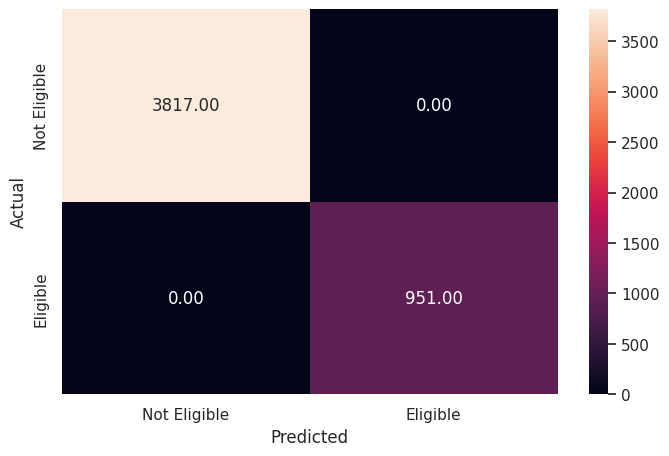

In [291]:
ytrain_pred_dt = dt_model.predict(X_train)
metrics_score(y_train, ytrain_pred_dt)

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       954
           1       0.72      0.63      0.67       238

    accuracy                           0.88      1192
   macro avg       0.81      0.79      0.80      1192
weighted avg       0.87      0.88      0.87      1192



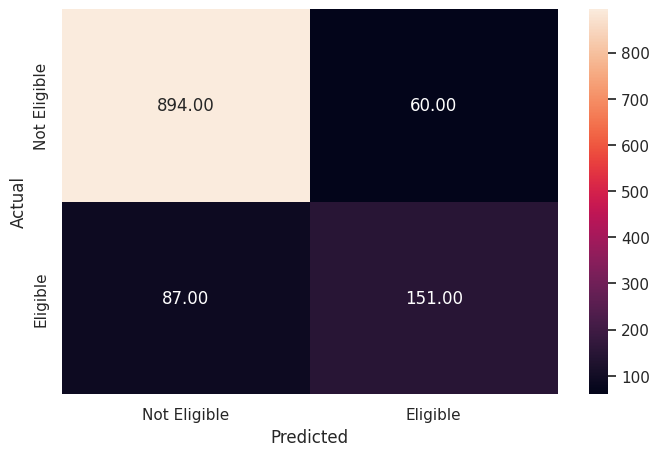

In [292]:
ytest_pred_dt = dt_model.predict(X_test)
metrics_score(y_test, ytest_pred_dt)


### Observations on Decision tree model:
*  The perfect training scores combined with lower test performance indicate some overfitting.
*  The model achieves good overall accuracy of 0.88 on the test data.
*  Precision and recall are high for the majority class (0), with precision = 0.91 and recall = 0.94.
* Performance is lower but still reasonable for the minority class (1), with precision = 0.72 and recall = 0.63.  
*  The reduced recall for class 1 suggests the model is missing some defaulters (false negatives), which could be critical in credit risk contexts. Further tuning might help improve minority class recall without sacrificing overall accuracy.








### **Decision Tree - Hyperparameter Tuning**

* Hyperparameter tuning is tricky in the sense that **there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of your model**, so we usually resort to experimentation. We'll use Grid search to perform hyperparameter tuning.
* **Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.**
* **It is an exhaustive search** that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are **optimized by cross-validated grid-search** over a parameter grid.

**Criterion {“gini”, “entropy”}**

The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.

**max_depth**

The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

**min_samples_leaf**

The minimum number of samples is required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

You can learn about more Hyperpapameters on this link and try to tune them.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


In [293]:
#For tuning the model
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
import sklearn.metrics as metrics
# Choose the type of classifier
dtree_estimator = DecisionTreeClassifier(class_weight = {0: 0.2, 1: 0.8}, random_state = 42)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 7),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
gridCV = GridSearchCV(dtree_estimator, parameters, scoring = scorer, cv = 5)

# Fitting the grid search on the train data
gridCV = gridCV.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
dtree_estimator = gridCV.best_estimator_

# Fit the best estimator to the data
dtree_estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, max_depth=np.int64(5),
                       min_samples_leaf=25, random_state=42)

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      3817
           1       0.62      0.79      0.70       951

    accuracy                           0.86      4768
   macro avg       0.78      0.84      0.80      4768
weighted avg       0.88      0.86      0.87      4768



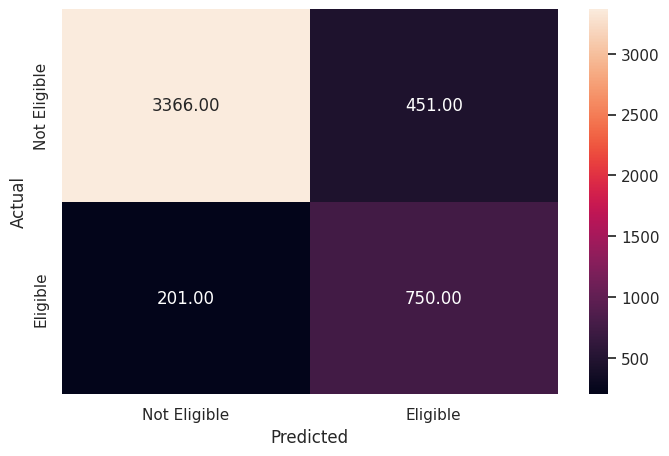

In [294]:
ytrain_tuned_dt = dtree_estimator.predict(X_train)
metrics_score(y_train, ytrain_tuned_dt)

              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1431
           1       0.57      0.76      0.65       357

    accuracy                           0.84      1788
   macro avg       0.75      0.81      0.77      1788
weighted avg       0.86      0.84      0.85      1788



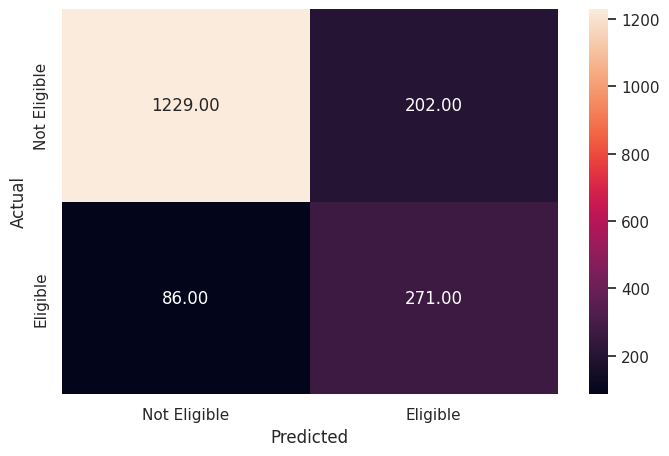

In [213]:
ytest_tuned_dt = dtree_estimator.predict(X_test)
metrics_score(y_test, ytest_tuned_dt)

### Observations on Decision tree tuned model:

* The tuned model performs well and generalizes effectively from train to test data.
* For the minority class (1), recall is relatively high at 0.79 in the training set and slightly lower at 0.75 in the test set, while precision remains consistent at 0.62 in both, indicating the model catches most defaulters but has some false positives.
### Lets plot the decision tree


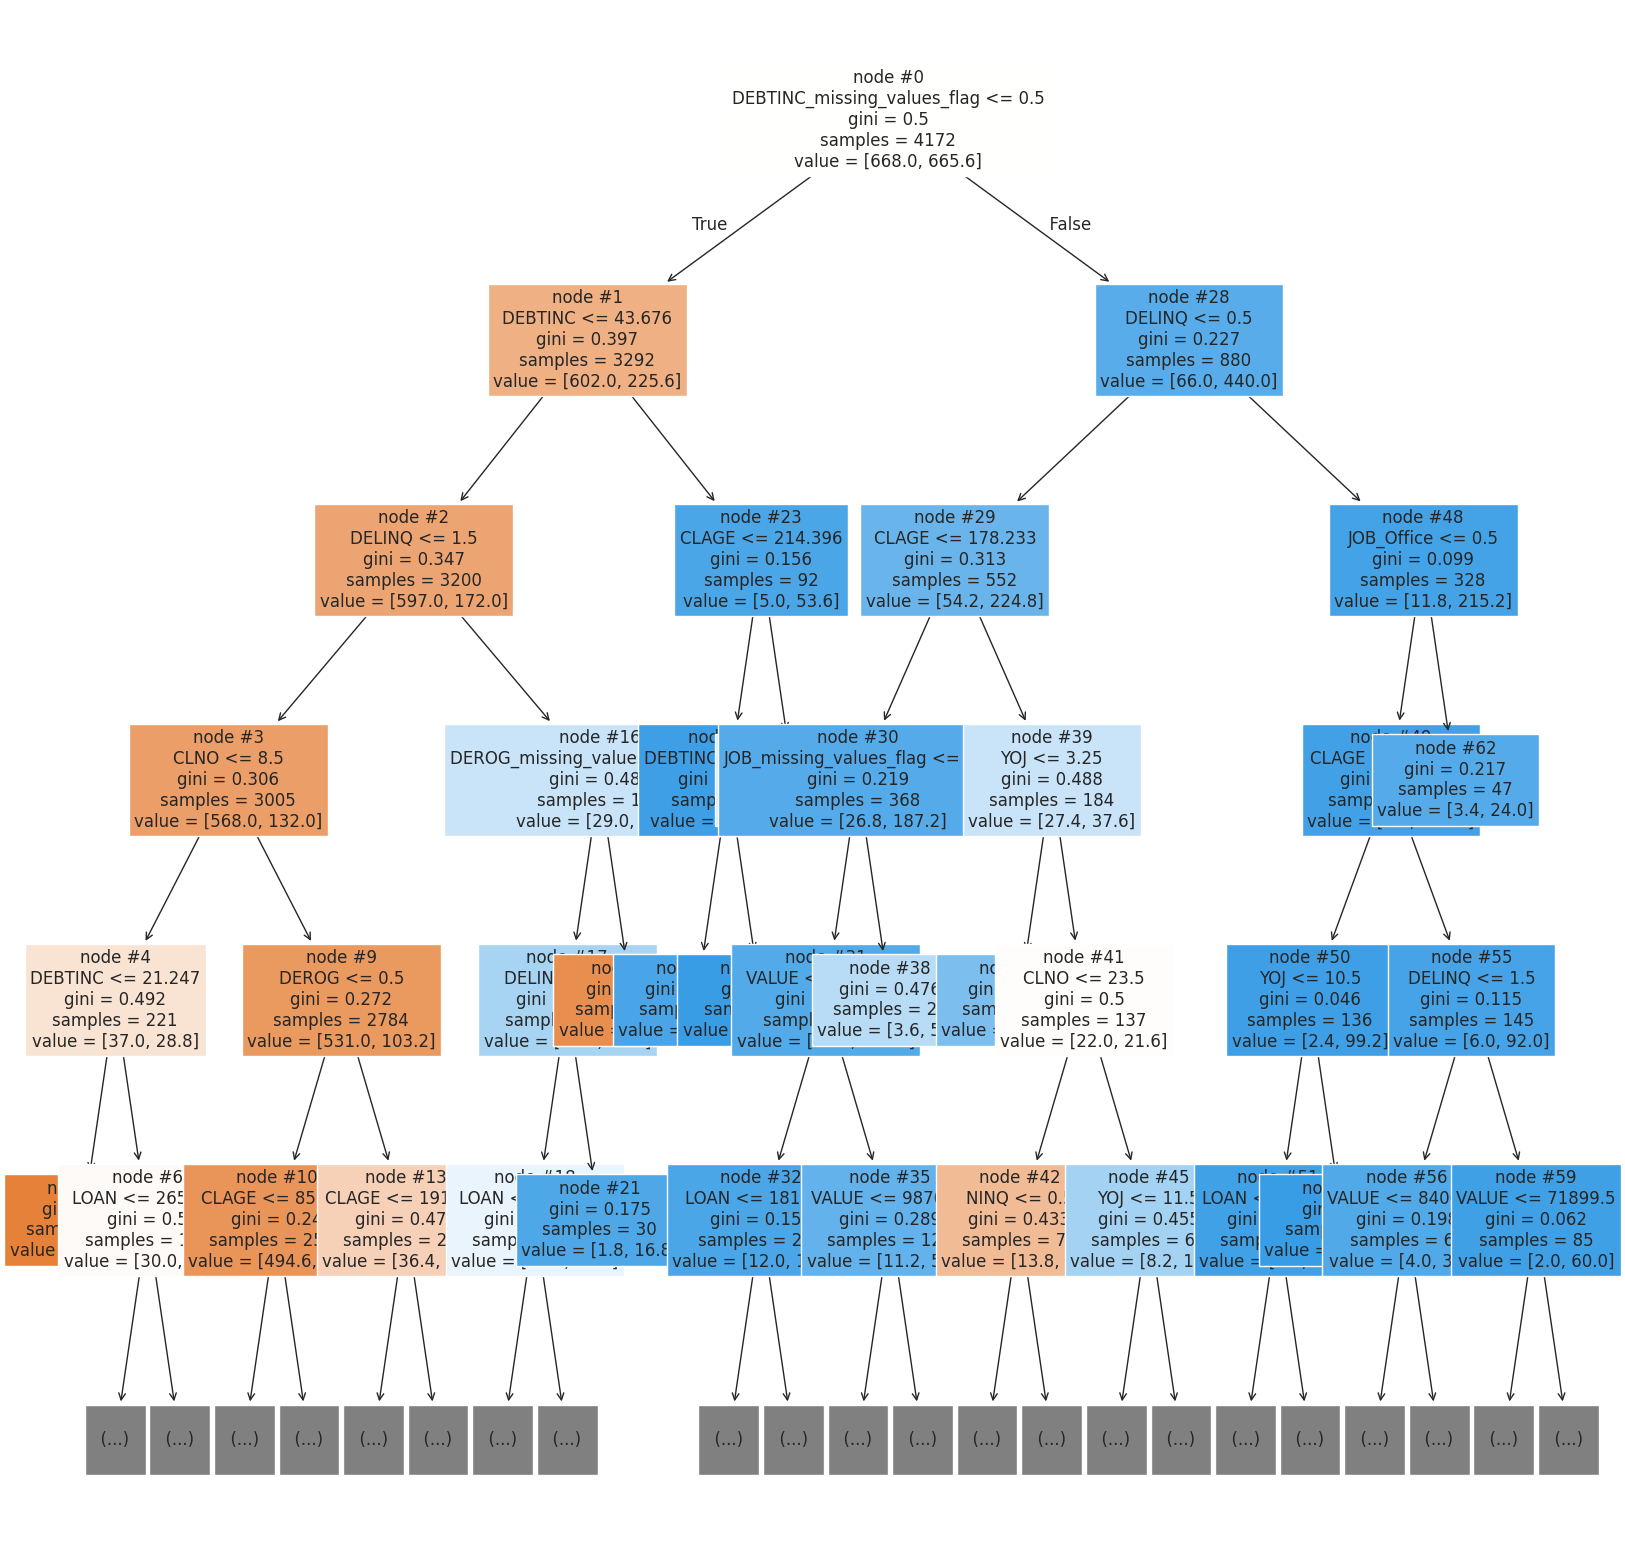

In [196]:
# code to plot decision tree
from sklearn import tree
features = list(X.columns)

plt.figure(figsize = (20, 20))

tree.plot_tree(dtree_estimator, max_depth = 5, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = None)

plt.show()

### Obssrvations:
Blue nodes indicate majority non-defaulters (BAD = 0), and orange nodes indicate majority defaulters (BAD = 1). The majority of leaves are blue, suggesting the dataset might have more non-defaulters.

* The first split is on DEBTINC_missing_values_flag, meaning whether the DEBTINC (debt-to-income ratio) is missing or not significantly influences the classification of defaulters (BAD).  
* Other missing value indicators like JOB_missing_values_flag and DEROG_missing_values_flag also appear in top splits, suggesting that patterns in missing data are predictive.
*  When DEBTINC <= 43.68, there is a higher likelihood of non-default.
* Higher values of DEBTINC are associated with more defaults, especially when combined with other risky indicators like recent delinquencies.
* Lower DELINQ (delinquencies) and DEROG (derogatory credit events) are strongly associated with non-defaulters. These variables show up early in the tree and help separate low-risk vs. high-risk individuals.
* Older credit history (CLAGE) and moderate-to-high number of credit lines (CLNO) tend to indicate lower risk.
* Individuals with recent credit history (low CLAGE) are more likely to be classified as defaulters.
* Higher property values are consistently associated with lower risk of default.
### Let's plot the feature importance and check the most important features.









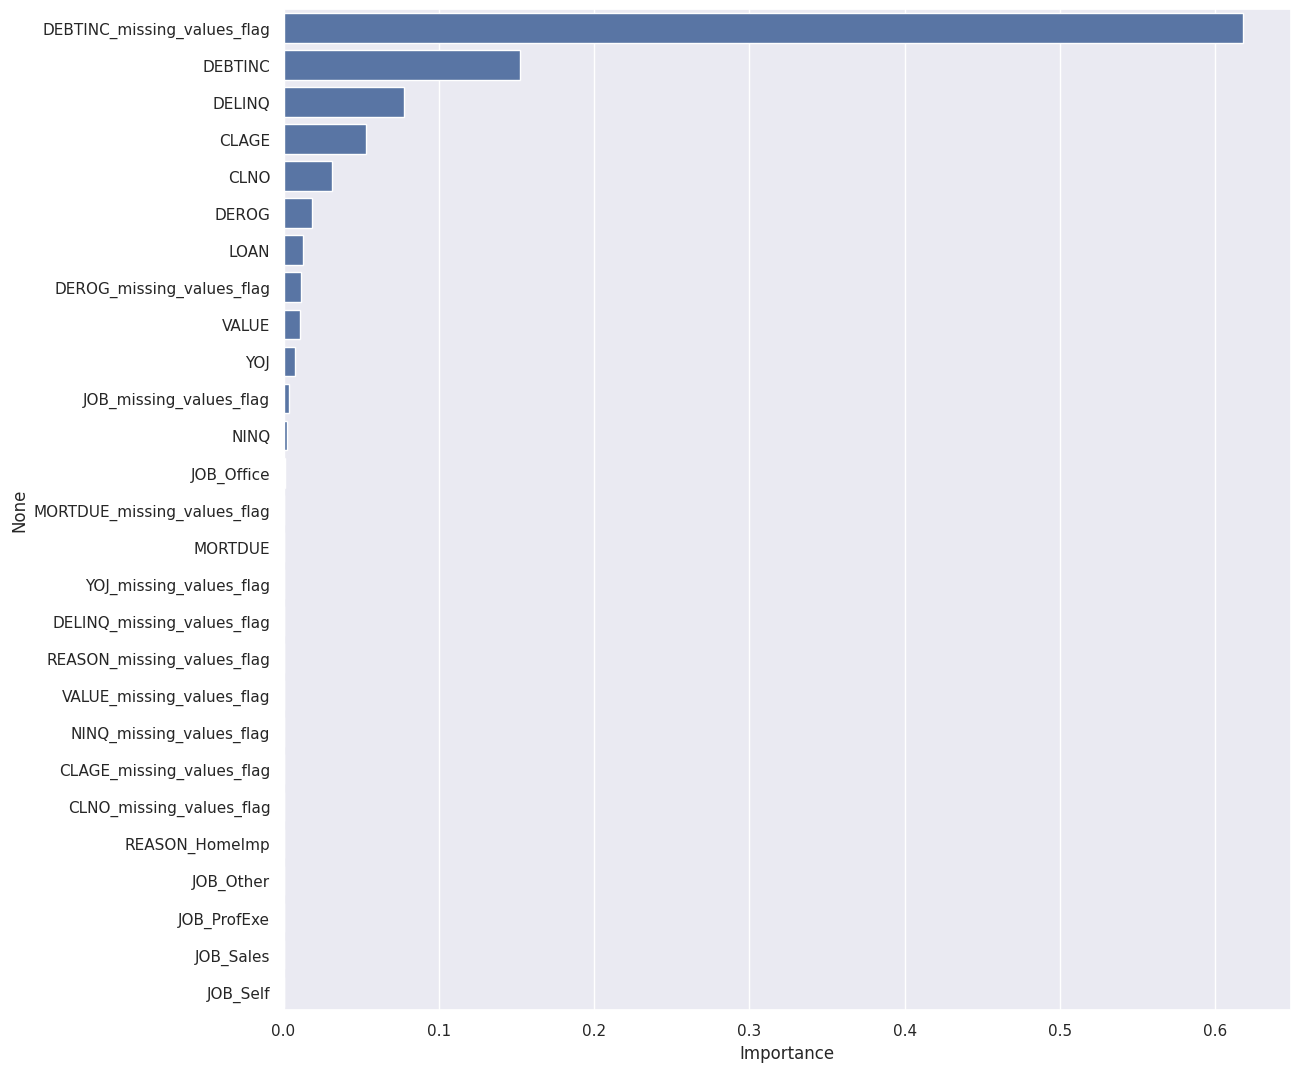

In [197]:
# Plot the feature importance

importances = dtree_estimator.feature_importances_

columns = X.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x=importance_df.Importance,y=importance_df.index);

###Observations:

* DEBTINC_missing_values_flag, DEBTINC, DELINQ, CLAGE, and CLNO stand out as the key features.
Additional significant features include DEROG_missing_value_flag, YOJ, and job_missing_values_flag.




### **Building a Random Forest Classifier**

**Random Forest is a bagging algorithm where the base models are Decision Trees.** Samples are taken from the training data and on each sample a decision tree makes a prediction.

**The results from all the decision trees are combined together and the final prediction is made using voting or averaging.**

In [127]:
# Fitting the Random Forest classifier on the training data
rf_model = RandomForestClassifier(random_state = 42,class_weight={0: 0.2, 1: 0.8})

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=42)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3817
           1       1.00      1.00      1.00       951

    accuracy                           1.00      4768
   macro avg       1.00      1.00      1.00      4768
weighted avg       1.00      1.00      1.00      4768



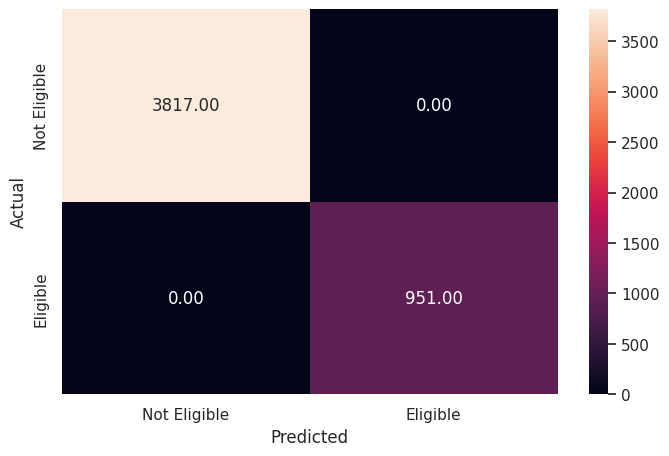

In [128]:
rf_train_model = rf_model.predict(X_train)
metrics_score(y_train, rf_train_model)

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       954
           1       0.80      0.62      0.70       238

    accuracy                           0.89      1192
   macro avg       0.86      0.79      0.82      1192
weighted avg       0.89      0.89      0.89      1192



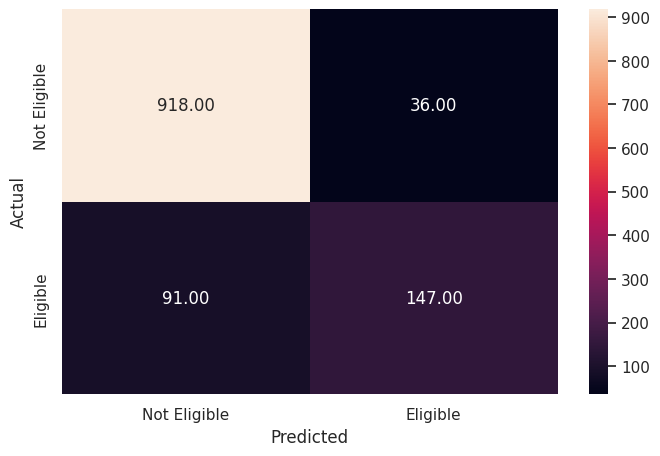

In [129]:
rf_test_model = rf_model.predict(X_test)
metrics_score(y_test, rf_test_model)

### Observations on RandomForestClassifier:

* The model achieves perfect scores across all metrics (precision, recall, and F1-score of 1.00 for both classes), indicating overfitting. While this suggests the model has learned the training data extremely well, it may not generalize effectively to new data.
### Test data
* For class 0 (non-defaulters), the model performs very well with a precision of 0.91 and recall of 0.96.  
* For class 1 (defaulters), recall drops to 0.62 (meaning some defaulters are missed), though precision remains decent at 0.80.  
* The overall accuracy is 0.89, and the macro F1-score is 0.82, indicating solid performance but a clear gap from the perfect training results.

Further regularization or tuning (e.g., limiting tree depth, adjusting min_samples_split) may help reduce overfitting and enhance generalization.






### **Random Forest Classifier Hyperparameter Tuning**

In [114]:
# Choose the type of classifier
rf_estimator_tuned = RandomForestClassifier(criterion = 'entropy', random_state = 42)

# Grid of parameters to choose from
params_rf = {
        "n_estimators": [100, 250, 500],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9, 'auto'],
        "max_samples": [0.9, 1],
    "class_weight": ["balanced",{0: 0.2, 1: 0.8}],
        "max_depth": [6, 7]
}


# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, params_rf, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

In [130]:
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, max_features=0.7, max_samples=0.9,
                       min_samples_leaf=np.int64(2), n_estimators=500,
                       random_state=42)

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      3817
           1       0.77      0.81      0.79       951

    accuracy                           0.91      4768
   macro avg       0.86      0.88      0.87      4768
weighted avg       0.92      0.91      0.91      4768



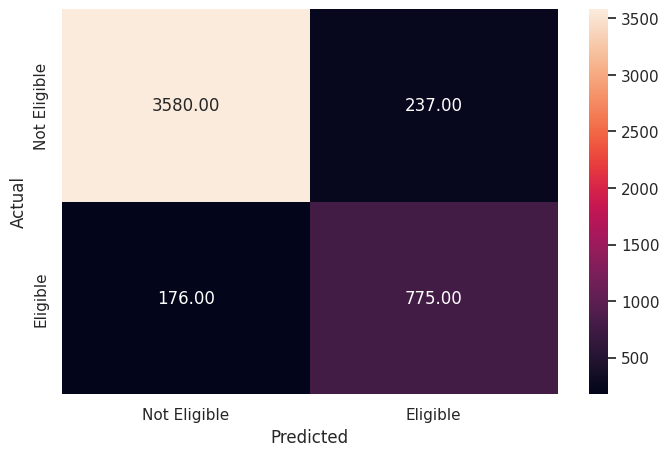

In [133]:
rf_tune_train = rf_tuned.predict(X_train)
metrics_score(y_train, rf_tune_train)

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       954
           1       0.71      0.73      0.72       238

    accuracy                           0.89      1192
   macro avg       0.82      0.83      0.82      1192
weighted avg       0.89      0.89      0.89      1192



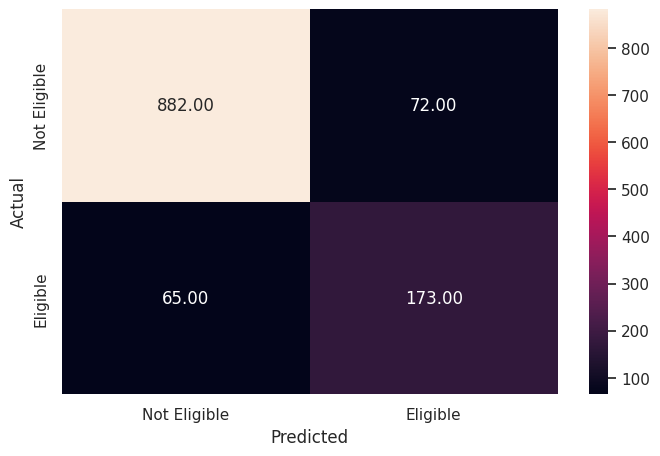

In [134]:
rf_test_tuned = rf_tuned.predict(X_test)
metrics_score(y_test, rf_test_tuned)

###Observation on Tuned RandomForestClassifier (GridSearchCV)
The tuned RandomForestClassifier demonstrates strong and balanced performance for both defaulters and non-defaulters. Recall for class 1 is relatively high on both training (0.81) and test data (0.73), which is especially important for identifying potential defaulters. The model generalizes well with no signs of overfitting, making it suitable for credit risk prediction tasks.

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, make_scorer
import numpy as np

# Classifier
rf_estimator_tuned = RandomForestClassifier(criterion='entropy', random_state=42)

# Expanded hyperparameter space for randomized search
params_rf = {
    "n_estimators": [100, 250, 500, 700],
    "min_samples_leaf": np.arange(1, 6),
    "min_samples_split": [2, 4, 6, 8, 10],
    "max_features": [0.7, 0.9, 'sqrt', 'log2'],
    "max_samples": [0.8, 0.9, 1],
    "class_weight": ["balanced", {0: 0.2, 1: 0.8}],
    "max_depth": [5, 6, 7, 8, 10]
}

# Scoring function to prioritize class 1 recall
scorer = make_scorer(recall_score, pos_label=1)

# RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator=rf_estimator_tuned,
    param_distributions=params_rf,
    n_iter=30,  # Number of combinations to try (can be increased)
    scoring=scorer,
    cv=5,
    random_state=1,
    verbose=2,
    n_jobs=-1,  # Use all CPU cores
    refit=True
)

# Fit the model
random_search.fit(X_train, y_train)

# Best model
rf_tuned1 = random_search.best_estimator_

# Optional: print best parameters
print("Best Parameters Found:\n", random_search.best_params_)



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters Found:
 {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': np.int64(4), 'max_samples': 0.9, 'max_features': 'log2', 'max_depth': 7, 'class_weight': 'balanced'}


In [136]:
rf_tuned1.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, max_features='log2', max_samples=0.9,
                       min_samples_leaf=np.int64(4), n_estimators=500,
                       random_state=42)

              precision    recall  f1-score   support

           0       0.95      0.90      0.93      3817
           1       0.67      0.82      0.74       951

    accuracy                           0.88      4768
   macro avg       0.81      0.86      0.83      4768
weighted avg       0.90      0.88      0.89      4768



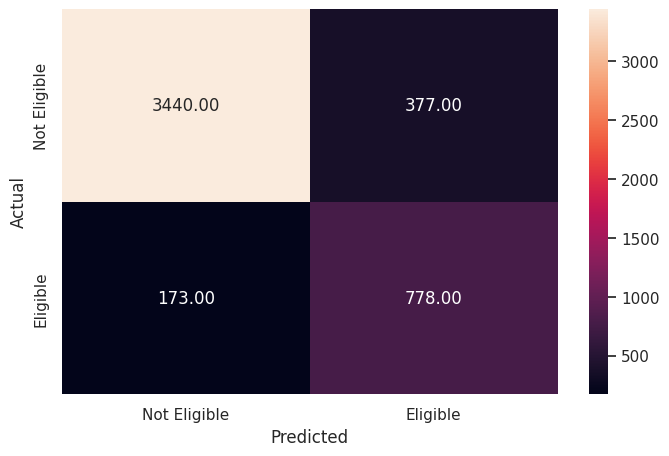

In [137]:
rf_tune1_train = rf_tuned1.predict(X_train)
metrics_score(y_train, rf_tune1_train)

              precision    recall  f1-score   support

           0       0.94      0.89      0.92       954
           1       0.64      0.78      0.70       238

    accuracy                           0.87      1192
   macro avg       0.79      0.84      0.81      1192
weighted avg       0.88      0.87      0.87      1192



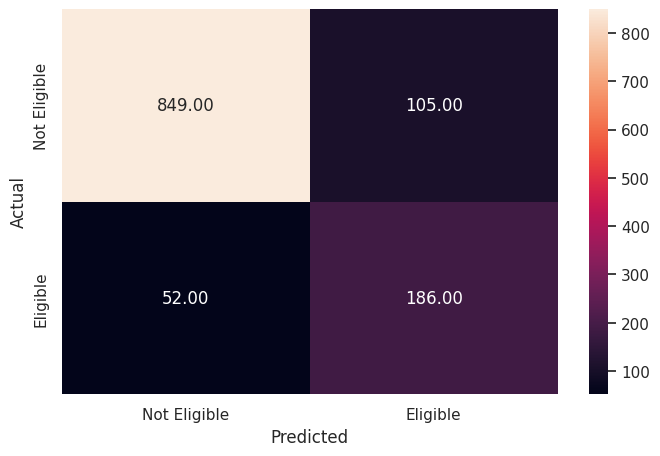

In [138]:
rf_test1_tuned = rf_tuned1.predict(X_test)
metrics_score(y_test, rf_test1_tuned)

### Observations on Tuned RandomForestClassifier (RandomizedSearchCV)

*  The tuned Random Forest model using RandomizedSearchCV performs well across both training and testing datasets. It shows strong capability in capturing defaulters (minority class) with good recall (0.82 for train and 0.78 for test) and acceptable precision, making it a reliable model for credit risk prediction. Further fine-tuning may help improve precision for class 1 without sacrificing recall.




**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success):**
Next I will define some function to compare the performance of all the models

In [278]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

def evaluate_model(model, X_train, y_train, X_test, y_test, verbose=False):
    """
    Evaluates a classification model on train and test data for accuracy, recall, and precision.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Train_Recall': recall_score(y_train, y_train_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Train_Precision': precision_score(y_train, y_train_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
    }

    if verbose:
        for metric, value in results.items():
            print(f"{metric}: {value:.4f}")

    return results

In [279]:
models = [lg, dt_model,dtree_estimator,rf_model,rf_tuned,rf_tuned1]
model_names = ['Logistic Regression', 'Decision Tree', 'Tuned decision tree',
               'Random Forest', 'Tuned random Forest with GridSearchCV',
               'Tuned random Forest with RandomizedSearchCV']
# Collect evaluation results
results_list = []
for model in models:
    results = evaluate_model(model, X_train, y_train, X_test, y_test)
    results_list.append(results)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results_list)
comparison_df.insert(0, 'Model', model_names)

# Display the result
comparison_df

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Logistic Regression,0.802972,0.800336,0.043269,0.042017,0.580645,0.500000
1,Decision Tree,0.935283,0.889262,0.712740,0.599440,0.950321,0.795539
2,Tuned decision tree,0.874880,0.864094,0.697115,0.677871,0.682353,0.654054
3,Random Forest,0.938878,0.888143,0.703125,0.498599,0.986509,0.894472
4,Tuned random Forest with GridSearchCV,0.886625,0.874161,0.656250,0.641457,0.744884,0.702454
5,Tuned random Forest with RandomizedSearchCV,0.870566,0.861857,0.737981,0.725490,0.655983,0.634804


###Model_Selection:

* The table shows that the tuned Random Forest model using RandomizedSearchCV achieves higher recall compared to the model tuned with GridSearchCV. Although its precision is slightly lower, we prioritize recall in this context because minimizing false negatives is critical—misclassifying defaulters as non-defaulters can lead to significant financial risk. Therefore, the model from RandomizedSearchCV is preferred due to its better ability to identify potential defaulters.





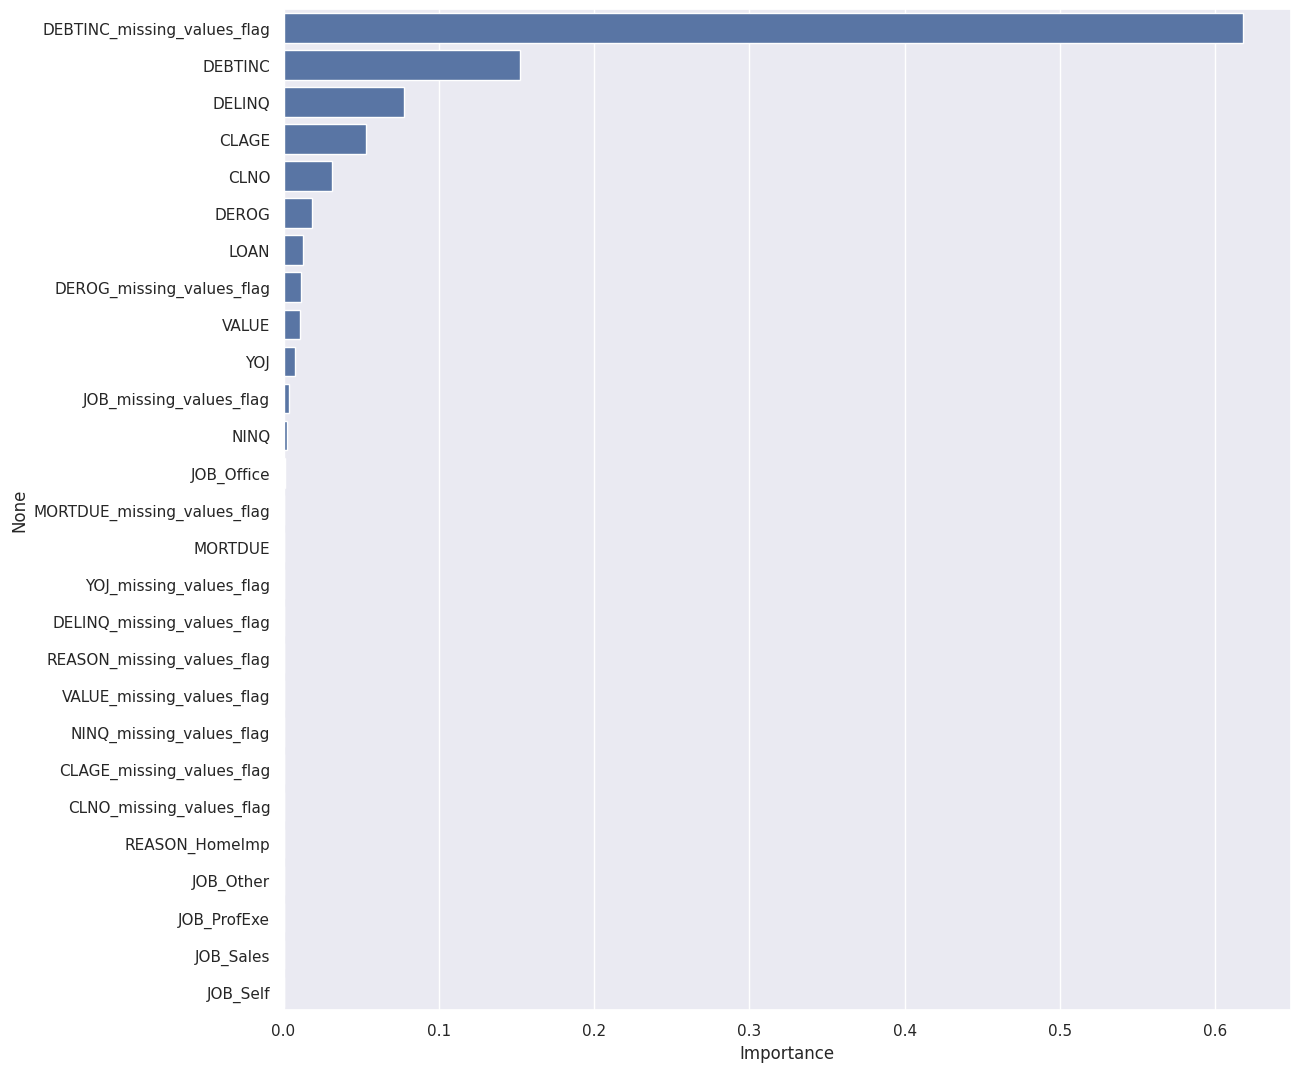

In [281]:
mportances = rf_tuned1.feature_importances_

columns = X.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x=importance_df.Importance,y=importance_df.index);

###Observations:

* For the Random Forest tuned model with RandomizedSearchCV, the most influential features are DEBTINC_missing_values_flag, DEBTINC, DELINQ, CLAGE, CLNO, and DEROG. Other notable contributors include DEROG_missing_value_flag, LOAN, YOJ, and job_missing_values_flag.




### Performance Enhancement Strategies
We can explore Gradient Boosting algorithms, which often perform better in capturing complex patterns. Additionally, generating interaction features (e.g., combining DEBTINC and DEROG) or transforming continuous variables into categorical bins (e.g., grouping YOJ into experience levels) may enhance model performance. Utilizing SHAP values can also provide deeper insights into feature contributions, helping us identify weaknesses and refine the input data accordingly.

**2. Refined insights:**
- Debt-to-income ratio (DEBTINC) is a strong predictor of default. The presence of missing values in this variable is also highly informative, suggesting that applicants with missing DEBTINC data may represent a riskier group.
- A high number of past delinquencies strongly correlates with higher default risk.
- Older credit lines (higher CLAGE) often indicate more stable and credit-experienced individuals.
- The total number of credit lines may reflect both borrowing behavior and creditworthiness.
- Presence and history of derogatory reports are important. Missing values here may also carry predictive value, indicating either data quality issues or applicant avoidance.
- Loan amount is a moderate predictor—higher loans may carry more risk if not supported by strong financial indicators.
- Longer employment stability (higher YOJ) typically implies a lower default risk. Missing job data may imply higher uncertainty or risk, and the model is sensitive to this absence.




**3. Proposal for the final solution design:**
- Encourage applicants to provide complete DEBTINC and job information, as missing values significantly impact risk prediction.
- Place additional weight on applicants with high DELINQ or DEROG values during credit evaluation and possibly tighten approval criteria.
- Prioritize robust employment verification processes, especially for applicants with missing or short YOJ.
- Develop tailored lending strategies based on DEBTINC and CLAGE—for example, offer lower interest rates to applicants with high CLAGE and low DEBTINC.